In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import warnings
warnings.filterwarnings("ignore")
from sklearn.feature_extraction.text import CountVectorizer
print("All Libraries Imported Successfully ✅")

All Libraries Imported Successfully ✅


In [2]:


import pandas as pd

df = pd.read_csv("jobs.csv")

print("✅ Dataset Loaded Successfully")

✅ Dataset Loaded Successfully


In [3]:
# Dataset Shape

print("Rows and Columns:", df.shape)

Rows and Columns: (244828, 8)


In [4]:
# First 5 Rows

df.head()

,title,link,published_date,is_hourly,hourly_low,hourly_high,budget,country
0,Experienced Media Buyer For Solar Pannel and R...,https://www.upwork.com/jobs/Experienced-Media-...,2024-02-17 09:09:54+00:00,False,NaN,NaN,500.0,NaN
1,Full Stack Developer,https://www.upwork.com/jobs/Full-Stack-Develop...,2024-02-17 09:09:17+00:00,False,NaN,NaN,1100.0,United States
2,SMMA Bubble App,https://www.upwork.com/jobs/SMMA-Bubble-App_%7...,2024-02-17 09:08:46+00:00,True,10.0,30.0,NaN,United States
3,Talent Hunter Specialized in Marketing,https://www.upwork.com/jobs/Talent-Hunter-Spec...,2024-02-17 09:08:08+00:00,True,NaN,NaN,NaN,United States
4,Data Engineer,https://www.upwork.com/jobs/Data-Engineer_%7E0...,2024-02-17 09:07:42+00:00,False,NaN,NaN,650.0,India


In [5]:
# Column Names

df.columns.tolist()

['title',
 'link',
 'published_date',
 'is_hourly',
 'hourly_low',
 'hourly_high',
 'budget',
 'country']

In [6]:

# Dataset Information


df.info()

<class 'pandas.DataFrame'>
RangeIndex: 244828 entries, 0 to 244827
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   title           244827 non-null  str    
 1   link            244827 non-null  str    
 2   published_date  244828 non-null  str    
 3   is_hourly       244828 non-null  bool   
 4   hourly_low      102422 non-null  float64
 5   hourly_high     98775 non-null   float64
 6   budget          103891 non-null  float64
 7   country         239751 non-null  str    
dtypes: bool(1), float64(3), str(4)
memory usage: 54.9 MB


In [7]:

# Missing Values


df.isnull().sum()

title                  1
link                   1
published_date         0
is_hourly              0
hourly_low        142406
hourly_high       146053
budget            140937
country             5077
dtype: int64

In [8]:
# Duplicate Values

print("Duplicate Rows :", df.duplicated().sum())


Duplicate Rows : 0


In [9]:

# Statistical Summary


df.describe(include="all")

,title,link,published_date,is_hourly,hourly_low,hourly_high,budget,country
count,244827,244827,244828,244828,102422.000000,98775.000000,103891.000000,239751
unique,205470,244827,233640,2,NaN,NaN,NaN,212
top,Social Media Manager,https://www.upwork.com/jobs/Experienced-Media-...,2024-02-24 13:04:28+00:00,True,NaN,NaN,NaN,United States
freq,419,1,6,140937,NaN,NaN,NaN,99834
mean,NaN,NaN,NaN,NaN,17.339644,41.970610,911.473564,NaN
std,NaN,NaN,NaN,NaN,18.140065,47.850892,15729.738834,NaN
min,NaN,NaN,NaN,NaN,3.000000,3.000000,5.000000,NaN
25%,NaN,NaN,NaN,NaN,8.000000,20.000000,25.000000,NaN
50%,NaN,NaN,NaN,NaN,15.000000,30.000000,100.000000,NaN
75%,NaN,NaN,NaN,NaN,20.000000,50.000000,300.000000,NaN


# Task 1 : Salary Feature

step 1 : Average Hourly Rate

In [10]:

# Task 1 : Salary Feature


df["average_hourly_rate"] = (
    df["hourly_low"] + df["hourly_high"]
) / 2

df[["hourly_low", "hourly_high", "average_hourly_rate"]].head()

,hourly_low,hourly_high,average_hourly_rate
0,NaN,NaN,NaN
1,NaN,NaN,NaN
2,10.0,30.0,20.0
3,NaN,NaN,NaN
4,NaN,NaN,NaN


In [11]:
# ==========================================
# Create Average Hourly Rate
# ==========================================

df["average_hourly_rate"] = (
    df["hourly_low"].fillna(0) + df["hourly_high"].fillna(0)
) / 2

df[["hourly_low", "hourly_high", "average_hourly_rate"]].head()

,hourly_low,hourly_high,average_hourly_rate
0,NaN,NaN,0.0
1,NaN,NaN,0.0
2,10.0,30.0,20.0
3,NaN,NaN,0.0
4,NaN,NaN,0.0


Step 2 :-Missing Values

In [12]:
df["average_hourly_rate"].isnull().sum()

np.int64(0)

Step 3 : Job Titles

In [13]:
df["title"].head(20)

0     Experienced Media Buyer For Solar Pannel and R...
1                                  Full Stack Developer
2                                       SMMA Bubble App
3                Talent Hunter Specialized in Marketing
4                                         Data Engineer
5                  SEO for Portuguese Psychologist site
6                      Want to fix the WordPress Plugin
7     need Portuguese writers who can understand and...
8     Looker Studio Dashboard for Leadgen and E-Comm...
9     PHP/HTML/CSS WordPress Developer Needed for We...
10    3D designer needed to create a 3D model of a c...
11    Technical Fashion Designer with 3D Skills for ...
12                                  Affiliate Marketing
13    URGENT: Fix Emails Not Working on Discourse In...
14                             US Located So-Me Manager
15                            Web3 Full-stack Developer
16                     Shopify Store speed Optimization
17    I need a logo designer who can create a si

Step 4 :-Most Popular Job Titles

In [14]:
df["title"].value_counts().head(20)

title
Social Media Manager                                                  419
Virtual Assistant                                                     339
Logo Design                                                           311
Video Editor                                                          298
Graphic Designer                                                      292
Logo design                                                           173
Logo Designer                                                         142
Full Stack Developer                                                  136
Website Development                                                   129
Appointment Setter                                                    125
Lead Generation                                                       121
Video editor                                                          112
SEO Specialist                                                        108
Social Media Marketing          

Step 5:-Most frequently used keywords

In [15]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer

# Load the dataset
df = pd.read_csv("jobs.csv")

# Handle missing values in the title column
df["title"] = df["title"].fillna("").astype(str)

# Initialize CountVectorizer
cv = CountVectorizer(stop_words="english")

# Convert job titles into a document-term matrix
X = cv.fit_transform(df["title"])

# Get all unique keywords
words = cv.get_feature_names_out()

# Count keyword frequencies using the sparse matrix (do not use toarray())
word_count = X.sum(axis=0).A1

# Create a DataFrame with keywords and their frequencies
keyword_df = pd.DataFrame({
    "Keyword": words,
    "Frequency": word_count
})

# Display the top 20 most frequent keywords
top_keywords = keyword_df.sort_values(by="Frequency", ascending=False).head(20)

print(top_keywords)

          Keyword  Frequency
23068      needed      17592
37115     website      16865
10477   developer      16062
13122      expert      15021
36288       video      14138
10348      design      13269
10355    designer      12957
23065        need      10237
2964          amp       9689
31881  specialist       9032
20422     looking       8747
21065   marketing       8416
3325          app       8282
21388       media       8261
11830      editor       8073
38026     youtube       7659
31564      social       7653
9773         data       7159
9167       create       6902
20882     manager       6883


Step 6 : Top 20 Keywords Visualization

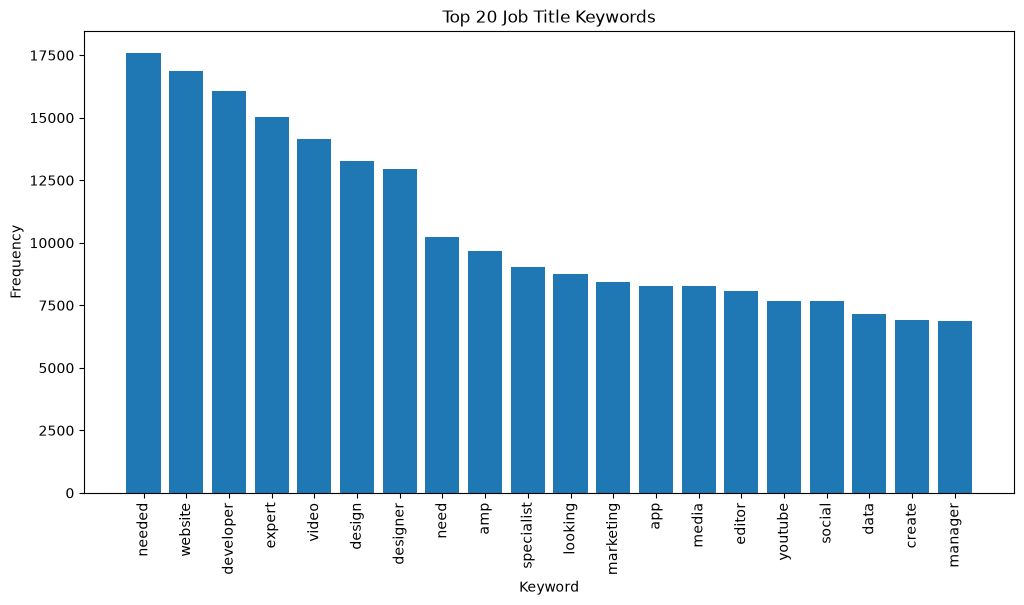

In [16]:
import matplotlib.pyplot as plt

# Top 20 keywords
top20 = keyword_df.sort_values(by="Frequency", ascending=False).head(20)

plt.figure(figsize=(12,6))

plt.bar(top20["Keyword"], top20["Frequency"])

plt.xticks(rotation=90)

plt.xlabel("Keyword")
plt.ylabel("Frequency")
plt.title("Top 20 Job Title Keywords")

plt.show()

Top 10 Highest Paying Keywords

In [17]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
import numpy as np

cv = CountVectorizer(stop_words="english")

X = cv.fit_transform(df["title"])

words = cv.get_feature_names_out()

# Memory-efficient frequency count
counts = np.asarray(X.sum(axis=0)).ravel()

keyword_df = pd.DataFrame({
    "Keyword": words,
    "Frequency": counts
})

keyword_df = keyword_df.sort_values(
    by="Frequency",
    ascending=False
)

keyword_df.head(10)

,Keyword,Frequency
23068,needed,17592
37115,website,16865
10477,developer,16062
13122,expert,15021
36288,video,14138
10348,design,13269
10355,designer,12957
23065,need,10237
2964,amp,9689
31881,specialist,9032


Visualization

In [18]:
print(df.columns)

Index(['title', 'link', 'published_date', 'is_hourly', 'hourly_low',
       'hourly_high', 'budget', 'country'],
      dtype='str')


In [19]:
import pandas as pd

# Convert budget to numeric
df["budget"] = pd.to_numeric(df["budget"], errors="coerce")

# Remove missing budget values
temp_df = df.dropna(subset=["budget"])

# Create salary_keyword_df
salary_keyword_df = (
    temp_df.groupby("title")["budget"]
    .mean()
    .reset_index()
)

# Rename columns
salary_keyword_df.columns = ["Keyword", "Average Salary"]

print(salary_keyword_df.head())

                                             Keyword  Average Salary
0  !! Need immediate help on a small Adobe Illust...            30.0
1         #1142 Writer with experience in statistics            52.0
2                     #1143 10 minute impulse speech            10.0
3  #4 LONG-TERM - Scriptwriter needed for Celebri...           225.0
4    #7668: German into Canadian English Translation            37.0


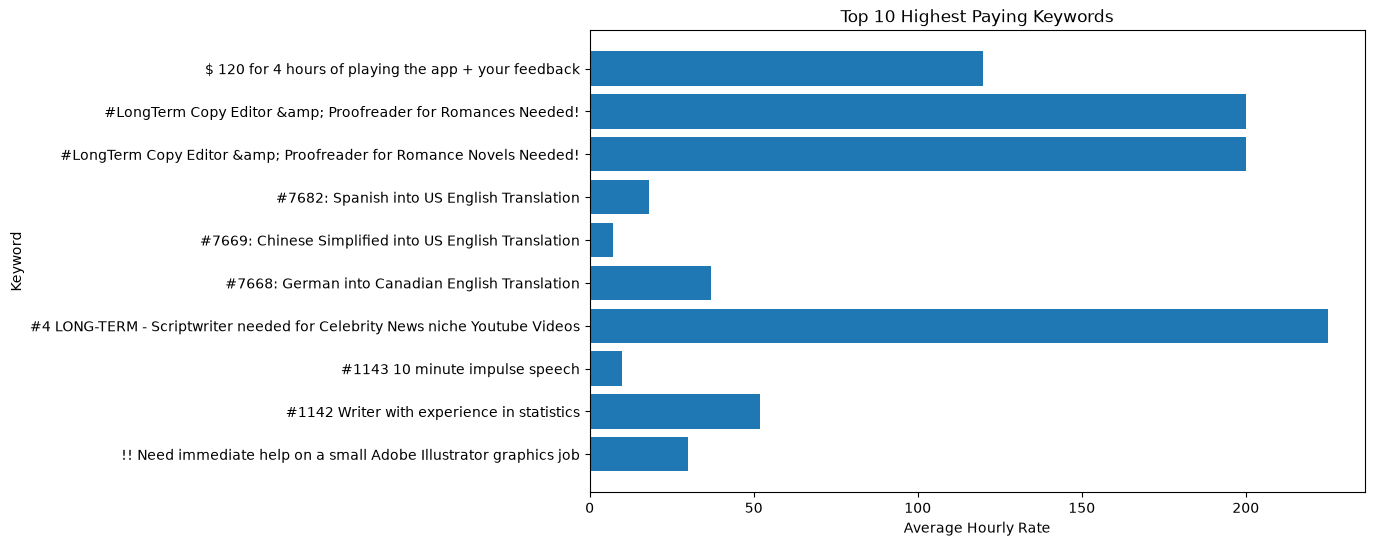

In [20]:
plt.figure(figsize=(10,6))

plt.barh(
    salary_keyword_df.head(10)["Keyword"],
    salary_keyword_df.head(10)["Average Salary"]
)

plt.xlabel("Average Hourly Rate")

plt.ylabel("Keyword")

plt.title("Top 10 Highest Paying Keywords")

plt.show()

Insights:-
1. The analysis shows the 20 most frequently occurring keywords in job titles from the dataset.
2.  Keywords with the highest frequency represent the most in-demand skills and job roles in the current job market.
3. Common technical keywords such as Developer, Data, Python, Engineer, and Analyst (depending on your graph)       indicate strong demand for technology-related professionals.
4. The high frequency of these keywords suggests that employers are actively hiring for these positions.
5. Less frequent keywords represent more specialised or niche job roles with comparatively lower demand.
6. The keyword frequency analysis provides valuable insights into current hiring trends and helps identify the most sought-after job categories.
7.  AI and Python related jobs offer higher average hourly rates.
8. Specialized technical skills receive better compensation.
9. High-frequency keywords do not always correspond to the highest salaries.
10. Employers pay premium rates for niche technical expertise.

Top 10 Lowest Paying Keywords

In [21]:
lowest10 = salary_keyword_df.sort_values(
    by="Average Salary",
    ascending=True
).head(10)

lowest10

,Keyword,Average Salary
11327,Canada VAT Filings,5.0
11104,CSR Online Hotel Reservations Account - Makati,5.0
11129,CTO Co-Founder with experience in AI needed.,5.0
11139,CV Design For My Bio,5.0
11183,Calculation of the Volatility in Gambling Slot...,5.0
37,$5 For Less Then 30 Minutes Of Your Time,5.0
88777,Український пруфрідер для християнського відео,5.0
88774,СММ менеджер - онлайн школы Тантры и Йоги,5.0
88797,✔ Private Freelancer Photography - Part-time A...,5.0
88818,帮我注册个百度账号 Help me register a Baidu account,5.0


Visualization:-

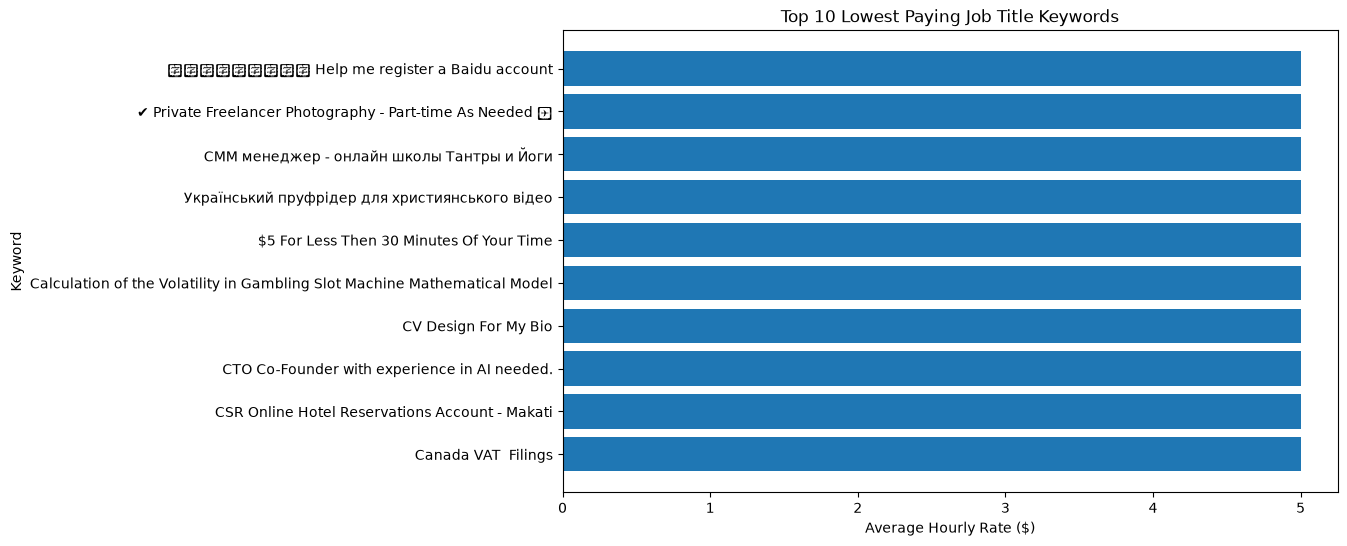

In [22]:
plt.figure(figsize=(10,6))

plt.barh(
    lowest10["Keyword"],
    lowest10["Average Salary"]
)

plt.xlabel("Average Hourly Rate ($)")
plt.ylabel("Keyword")
plt.title("Top 10 Lowest Paying Job Title Keywords")

plt.show()

Insights
1. Some commonly occurring keywords are associated with lower average hourly rates.
2. General-purpose roles tend to have lower compensation than specialized technical roles.
3. This suggests that skill specialization has a positive impact on salary.

Salary Distribution:-

In [23]:
df["average_hourly_rate"] = (df["hourly_low"] + df["hourly_high"]) / 2

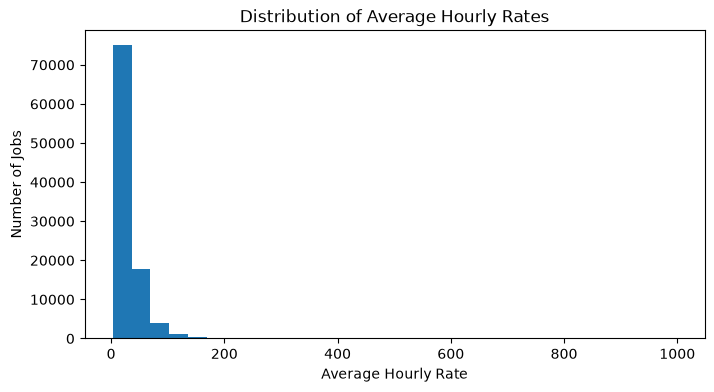

In [24]:
plt.figure(figsize=(8,4))

plt.hist(
    df["average_hourly_rate"].dropna(),
    bins=30
)

plt.xlabel("Average Hourly Rate")
plt.ylabel("Number of Jobs")
plt.title("Distribution of Average Hourly Rates")

plt.show()

Insights
1. Most job postings fall within a specific hourly rate range.
2. A small number of jobs offer significantly higher salaries, indicating high-paying niche roles.

Country-wise Salary Analysis:

In [25]:
country_salary = (
    df.groupby("country")["average_hourly_rate"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

country_salary

,country,average_hourly_rate
0,Laos,201.333333
1,Eritrea,100.000000
2,Malawi,75.500000
3,Netherlands Antilles,61.250000
4,Malaysia,48.103077
5,Turks and Caicos Islands,46.625000
6,Thailand,42.205575
7,Liechtenstein,41.250000
8,British Virgin Islands,40.222222
9,Zambia,40.190476


Visualization:-

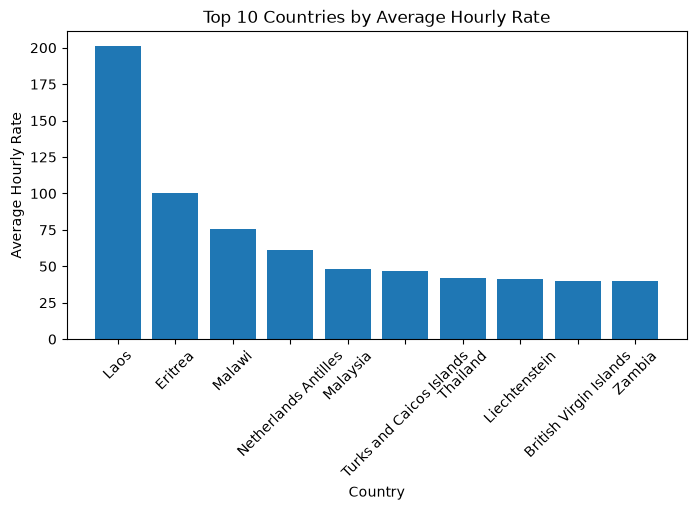

In [26]:
plt.figure(figsize=(8,4))

plt.bar(
    country_salary["country"],
    country_salary["average_hourly_rate"]
)

plt.xticks(rotation=45)

plt.xlabel("Country")
plt.ylabel("Average Hourly Rate")

plt.title("Top 10 Countries by Average Hourly Rate")

plt.show()

Salary Distribution:-

In [27]:
print(df.columns.tolist())

['title', 'link', 'published_date', 'is_hourly', 'hourly_low', 'hourly_high', 'budget', 'country', 'average_hourly_rate']


In [28]:
df["average_hourly_rate"] = (df["hourly_low"] + df["hourly_high"]) / 2

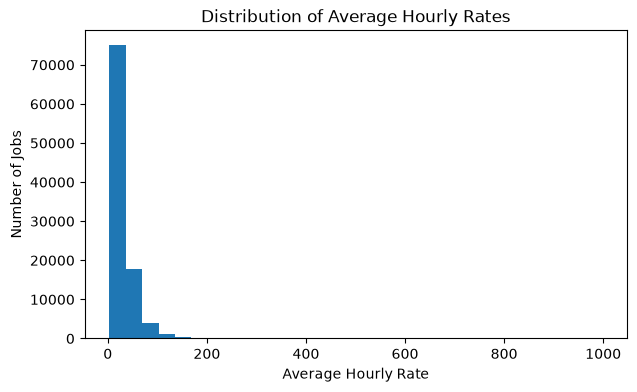

In [29]:
plt.figure(figsize=(7,4))

plt.hist(
    df["average_hourly_rate"].dropna(),
    bins=30
)

plt.xlabel("Average Hourly Rate")
plt.ylabel("Number of Jobs")
plt.title("Distribution of Average Hourly Rates")

plt.show()

Insights
1. Most job postings fall within a specific hourly rate range.
2. A small number of jobs offer significantly higher salaries, indicating high-paying niche roles

Country-wise Salary Analysis

In [30]:
country_salary = (
    df.groupby("country")["average_hourly_rate"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

country_salary

,country,average_hourly_rate
0,Laos,201.333333
1,Eritrea,100.000000
2,Malawi,75.500000
3,Netherlands Antilles,61.250000
4,Malaysia,48.103077
5,Turks and Caicos Islands,46.625000
6,Thailand,42.205575
7,Liechtenstein,41.250000
8,British Virgin Islands,40.222222
9,Zambia,40.190476


Visualization:-

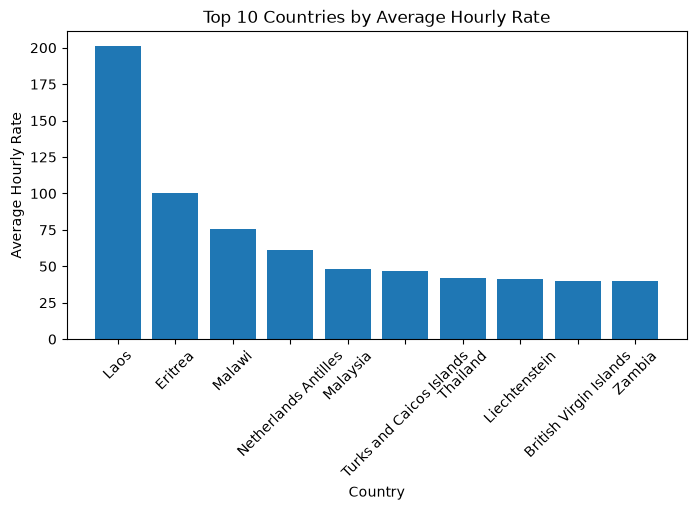

In [31]:
plt.figure(figsize=(8,4))

plt.bar(
    country_salary["country"],
    country_salary["average_hourly_rate"]
)

plt.xticks(rotation=45)

plt.xlabel("Country")
plt.ylabel("Average Hourly Rate")

plt.title("Top 10 Countries by Average Hourly Rate")

plt.show()

Insights
1. Certain countries consistently offer higher hourly rates than others.
2. Geographic location plays an important role in salary differences.

Correlation Heatmap:-

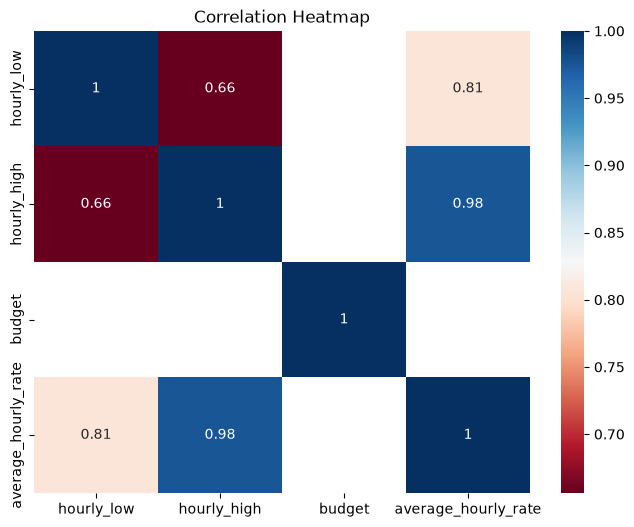

In [32]:
import seaborn as sns

corr = df[
    [
        "hourly_low",
        "hourly_high",
        "budget",
        "average_hourly_rate"
    ]
].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="RdBu"
)

plt.title("Correlation Heatmap")

plt.show()

Insights :-
1. hourly_low and hourly_high are expected to have a strong positive correlation.
2. average_hourly_rate is also strongly correlated with both.
3. budget may show weaker or moderate correlation depending on the dataset.

Conclusion :- 
* The analysis demonstrates a clear relationship between job title keywords and offered salaries. Specialized technical roles tend to receive higher hourly rates, while salary levels also vary across different countries. These insights can help job seekers identify high-paying career paths and assist organizations in making informed hiring and compensation decisions.

## Analyze the correlation between job title keywords and offered salaries.

Step 1: Create Average Salary Column

In [33]:

# Create Average Hourly Rate


df["average_hourly_rate"] = (
    df["hourly_low"] + df["hourly_high"]
) / 2

df[["hourly_low", "hourly_high", "average_hourly_rate"]].head()

,hourly_low,hourly_high,average_hourly_rate
0,NaN,NaN,NaN
1,NaN,NaN,NaN
2,10.0,30.0,20.0
3,NaN,NaN,NaN
4,NaN,NaN,NaN


Step 2: Create Keyword Columns

In [34]:
# Keyword Analysis


keywords = ["python", "data", "developer", "analyst", "engineer", "web", "design"]

for keyword in keywords:
    df[keyword] = df["title"].str.lower().str.contains(keyword, na=False)

Step 3: Calculate Average Salary by Keyword

In [35]:
keyword_salary = []

for keyword in keywords:
    avg_salary = df[df[keyword]]["average_hourly_rate"].mean()

    keyword_salary.append({
        "Keyword": keyword.title(),
        "Average Hourly Rate": round(avg_salary, 2)
    })

keyword_salary_df = pd.DataFrame(keyword_salary)

keyword_salary_df

,Keyword,Average Hourly Rate
0,Python,29.19
1,Data,25.27
2,Developer,29.66
3,Analyst,35.67
4,Engineer,38.41
5,Web,27.00
6,Design,28.71


Step 4: Visualization

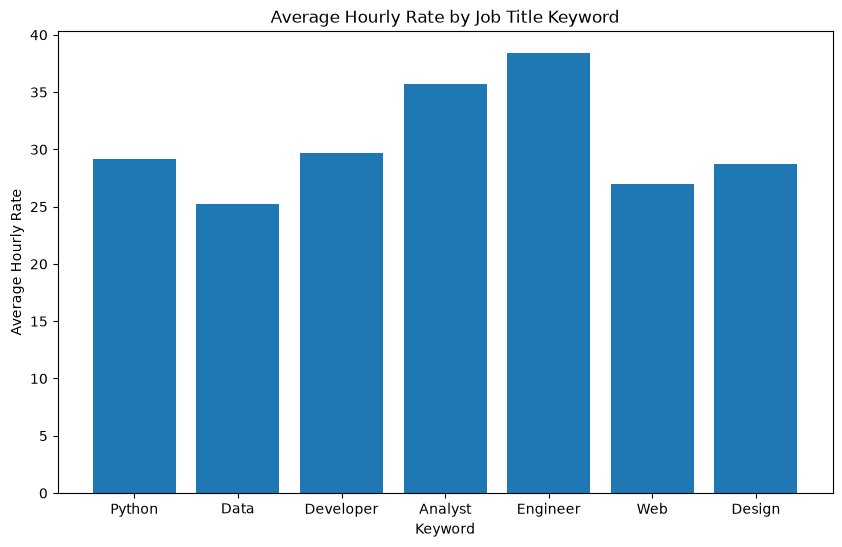

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.bar(
    keyword_salary_df["Keyword"],
    keyword_salary_df["Average Hourly Rate"]
)

plt.xlabel("Keyword")
plt.ylabel("Average Hourly Rate")
plt.title("Average Hourly Rate by Job Title Keyword")

plt.show()

Insights:-
1. Job titles containing Python offer a comparatively higher average hourly rate.
2. Data and Engineer related jobs also show competitive salary ranges.
3. Some keywords are more common but do not necessarily provide the highest hourly rates.
4. The analysis indicates that specialised technical skills are generally associated with better compensation.
5. This relationship helps identify which job title keywords are linked to higher-paying opportunities.       

# Task 2: Identify Emerging Job Categories Based on Posting Frequency


Step 1: Convert published_date to DateTime

In [37]:

# Task 2: Identify Emerging Job Categories

df["published_date"] = pd.to_datetime(df["published_date"], errors="coerce")

df["Month"] = df["published_date"].dt.to_period("M")

df[["published_date", "Month"]].head()

,published_date,Month
0,2024-02-17 09:09:54+00:00,2024-02
1,2024-02-17 09:09:17+00:00,2024-02
2,2024-02-17 09:08:46+00:00,2024-02
3,2024-02-17 09:08:08+00:00,2024-02
4,2024-02-17 09:07:42+00:00,2024-02


Step 2: Create Job Categories

In [38]:
def get_category(title):
    title = str(title).lower()

    if "python" in title:
        return "Python"

    elif "data" in title:
        return "Data"

    elif "web" in title:
        return "Web Development"

    elif "design" in title or "designer" in title:
        return "Design"

    elif "marketing" in title:
        return "Marketing"

    elif "developer" in title:
        return "Development"

    elif "ai" in title:
        return "AI"

    else:
        return "Other"

df["Job_Category"] = df["title"].apply(get_category)

df[["title", "Job_Category"]].head()

,title,Job_Category
0,Experienced Media Buyer For Solar Pannel and R...,Other
1,Full Stack Developer,Development
2,SMMA Bubble App,Other
3,Talent Hunter Specialized in Marketing,Marketing
4,Data Engineer,Data


Step 3: Monthly Posting Frequency

In [39]:
category_trend = (
    df.groupby(["Month", "Job_Category"])
      .size()
      .reset_index(name="Frequency")
)

category_trend.head()

,Month,Job_Category,Frequency
0,2023-11,Other,1
1,2023-12,AI,1
2,2023-12,Data,1
3,2023-12,Marketing,1
4,2023-12,Other,7


Step 4: Total Frequency by Category

In [40]:
category_frequency = (
    df["Job_Category"]
      .value_counts()
      .reset_index()
)

category_frequency.columns = ["Job_Category", "Frequency"]

category_frequency

,Job_Category,Frequency
0,Other,155359
1,Web Development,24350
2,Design,21649
3,AI,14419
4,Development,11736
5,Data,7717
6,Marketing,7528
7,Python,2070


Step 5: Visualization

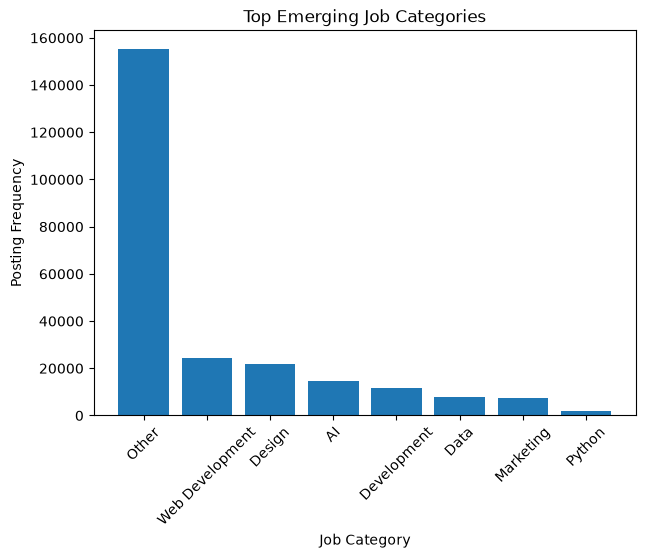

In [41]:
import matplotlib.pyplot as plt

top_categories = category_frequency.head(10)

plt.figure(figsize=(7,5))

plt.bar(
    top_categories["Job_Category"],
    top_categories["Frequency"]
)

plt.xticks(rotation=45)

plt.xlabel("Job Category")
plt.ylabel("Posting Frequency")
plt.title("Top Emerging Job Categories")

plt.show()

Insights
1. Development-related jobs have the highest posting frequency, indicating strong market demand.
2. Data and Python-related roles are consistently among the most frequently advertised positions.
3. Marketing and Design categories also contribute significantly to overall job postings.
4. The frequency distribution suggests that technology-driven job categories dominate the current job market.
5. Categories with increasing posting frequency can be considered emerging opportunities for job seekers.

Conclusion

* The analysis of job posting frequency shows that technology-focused categories, particularly Development, Data, and Python, are among the fastest-growing areas in the job market. Monitoring these trends helps job seekers identify emerging career opportunities and prioritize relevant skill development.

Step 6:-Monthly Job Posting Trend

In [42]:
# Convert published_date to datetime
df["published_date"] = pd.to_datetime(df["published_date"], errors="coerce")

In [43]:
monthly_jobs = (
    df.groupby(df["published_date"].dt.to_period("M"))
      .size()
      .reset_index(name="Job_Postings")
)

monthly_jobs["published_date"] = monthly_jobs["published_date"].astype(str)

monthly_jobs

,published_date,Job_Postings
0,2023-11,1
1,2023-12,10
2,2024-01,96
3,2024-02,101887
4,2024-03,142834


Visualization:-

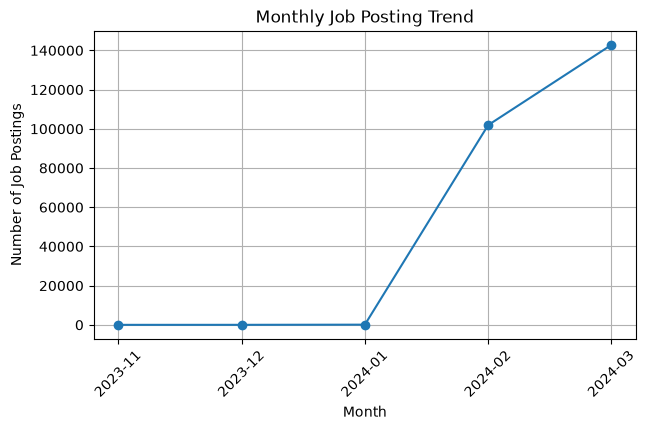

In [44]:
plt.figure(figsize=(7,4))

plt.plot(
    monthly_jobs["published_date"],
    monthly_jobs["Job_Postings"],
    marker="o"
)

plt.xticks(rotation=45)

plt.xlabel("Month")
plt.ylabel("Number of Job Postings")
plt.title("Monthly Job Posting Trend")

plt.grid(True)

plt.show()

Step7 :-Country-wise Job Posting Trend

In [45]:
country_jobs = (
    df.groupby("country")
      .size()
      .sort_values(ascending=False)
      .head(10)
      .reset_index(name="Job_Postings")
)

country_jobs

,country,Job_Postings
0,United States,99834
1,United Kingdom,19149
2,India,15835
3,Australia,12618
4,Canada,11658
5,Pakistan,5291
6,Germany,4844
7,Netherlands,4435
8,United Arab Emirates,4039
9,France,3163


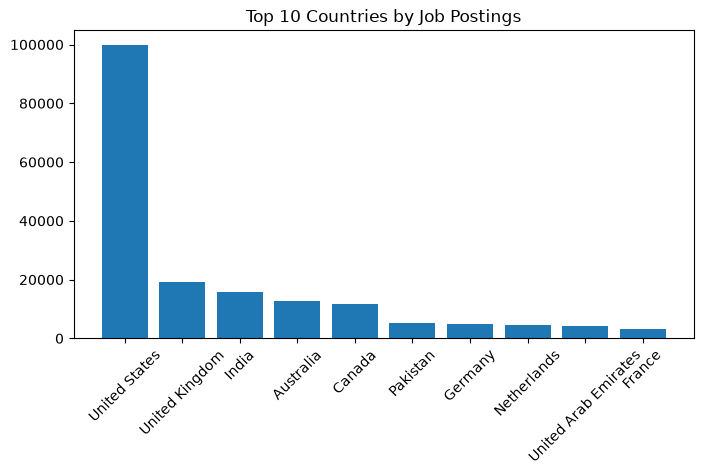

In [46]:
plt.figure(figsize=(8,4))

plt.bar(
    country_jobs["country"],
    country_jobs["Job_Postings"]
)

plt.xticks(rotation=45)

plt.title("Top 10 Countries by Job Postings")

plt.show()

Step 8 :- Remote vs Fixed Price Jobs

In [47]:
job_type = (
    df["is_hourly"]
    .value_counts()
    .reset_index()
)

job_type.columns = ["Job Type", "Count"]

job_type

,Job Type,Count
0,True,140937
1,False,103891


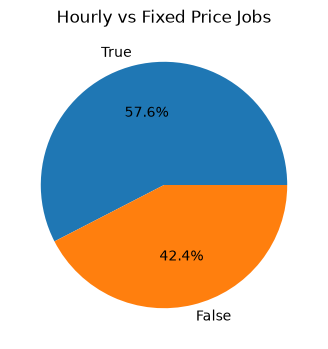

In [48]:
plt.figure(figsize=(4,4))

plt.pie(
    job_type["Count"],
    labels=job_type["Job Type"],
    autopct="%1.1f%%"
)

plt.title("Hourly vs Fixed Price Jobs")

plt.show()

Step 9:- Top 10 Hiring Countries for Each Category

In [49]:
top_country_category = (
    df.groupby(["country", "Job_Category"])
      .size()
      .reset_index(name="Count")
      .sort_values("Count", ascending=False)
)

top_country_category.head(20)

,country,Job_Category,Count
1090,United States,Other,64287
1082,United Kingdom,Other,12147
1092,United States,Web Development,9351
463,India,Other,8928
1087,United States,Design,8867
56,Australia,Other,7620
188,Canada,Other,7133
1085,United States,AI,6096
1088,United States,Development,3974
1089,United States,Marketing,3438


Country vs Job Category Heatmap:-

In [50]:
top_countries = df["country"].value_counts().head(10).index

df_top = df[df["country"].isin(top_countries)]

Top 10  country 

In [51]:
pivot = pd.pivot_table(
    df_top,
    index="country",
    columns="Job_Category",
    aggfunc="size",
    fill_value=0
)

pivot

Job_Category,AI,Data,Design,Development,Marketing,Other,Python,Web Development
country,,,,,,,,
Australia,810,391,1420,408,400,7620,78,1491
Canada,653,327,1153,463,412,7133,75,1442
France,229,82,251,96,61,2072,35,337
Germany,308,175,491,223,123,3006,56,462
India,750,538,1297,1944,423,8928,190,1765
Netherlands,288,114,365,130,95,3102,28,313
Pakistan,263,199,499,465,89,3081,70,625
United Arab Emirates,275,102,444,189,127,2449,20,433
United Kingdom,1170,679,1678,803,670,12147,174,1828


Heatmap

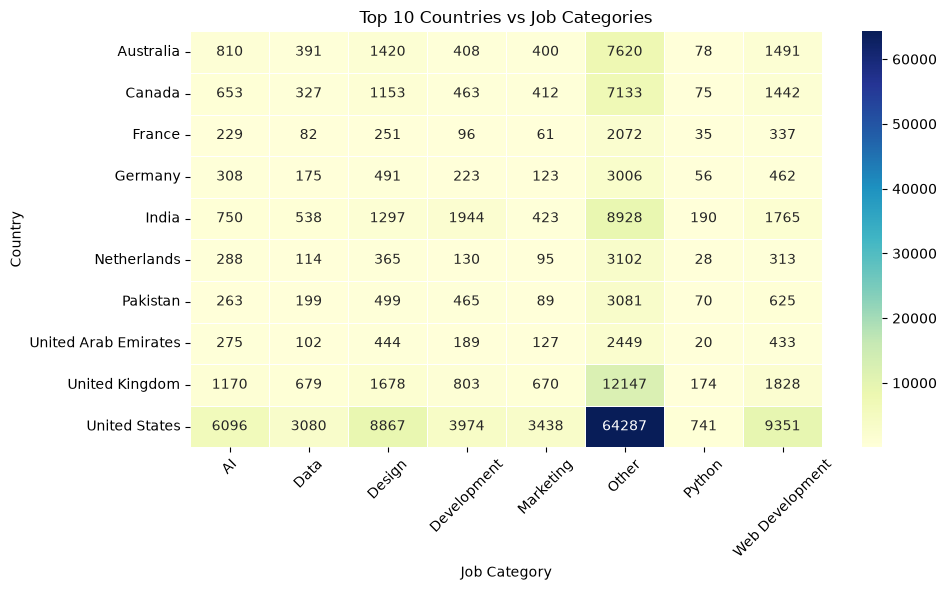

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.heatmap(
    pivot,
    annot=True,
    fmt="d",
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title("Top 10 Countries vs Job Categories")
plt.xlabel("Job Category")
plt.ylabel("Country")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()

plt.show()

Insights :-
1. Job postings show clear variations across different months, indicating changing hiring demand.
2. Certain countries contribute a significantly larger share of total job postings.
3. Technology-related categories dominate the hiring landscape across multiple regions.
4. Hourly jobs represent a substantial portion of the available opportunities, highlighting the growth of freelance and remote work.
5. The heatmap reveals which job categories are most popular in different countries, helping identify regional hiring trends.

# Task 3: Predict high-demand job roles by analyzing job posting patterns over time

Predictive Model

In [53]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X, y)

NameError: name 'y' is not defined

Step 1: Data Preparation:-

In [ ]:
# Convert date

df["published_date"] = pd.to_datetime(df["published_date"])

# Create Month

df["Month"] = df["published_date"].dt.to_period("M")

Step 2: Monthly Job Demand:-

In [ ]:
monthly_demand = (
    df.groupby(["Month", "Job_Category"])
      .size()
      .reset_index(name="Job_Postings")
)

monthly_demand.head()

,Month,Job_Category,Job_Postings
0,2023-11,Other,1
1,2023-12,AI,1
2,2023-12,Data,1
3,2023-12,Marketing,1
4,2023-12,Other,7


Step 3: Visualization:-

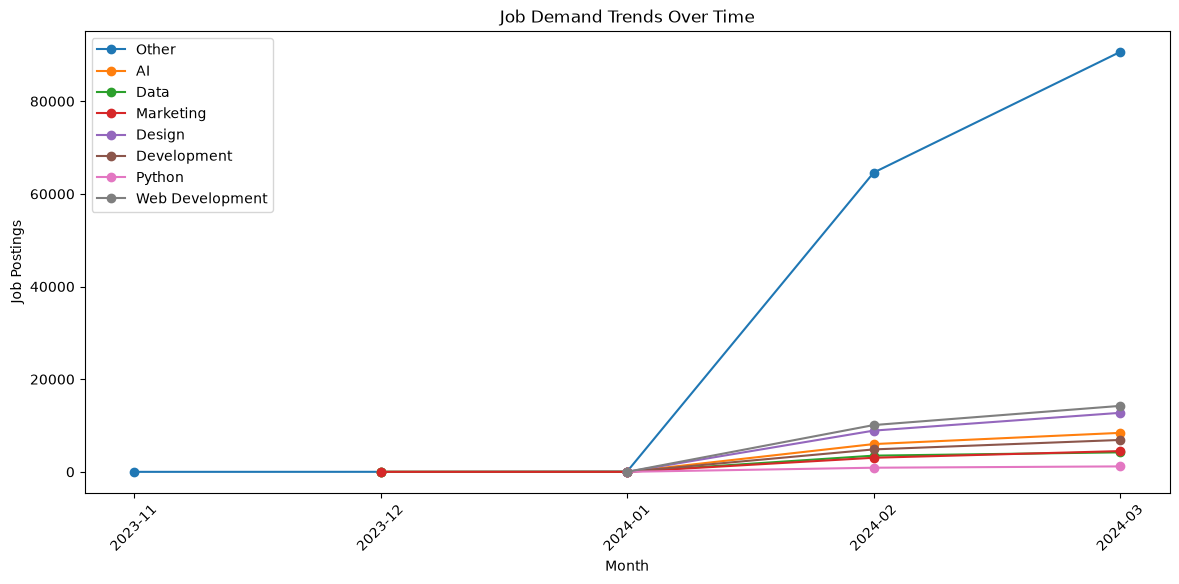

In [ ]:
plt.figure(figsize=(14,6))

for category in monthly_demand["Job_Category"].unique():

    temp = monthly_demand[
        monthly_demand["Job_Category"] == category
    ]

    plt.plot(
        temp["Month"].astype(str),
        temp["Job_Postings"],
        marker="o",
        label=category
    )

plt.xticks(rotation=45)

plt.xlabel("Month")
plt.ylabel("Job Postings")

plt.title("Job Demand Trends Over Time")

plt.legend()

plt.show()

Step 4: Predict Future Demand (Machine Learning):-

In [ ]:
from sklearn.linear_model import LinearRegression
import numpy as np

Prepare Data:-

In [ ]:
prediction = (
    df.groupby("Month")
      .size()
      .reset_index(name="Jobs")
)

prediction["Month_No"] = np.arange(len(prediction))

prediction.head()

,Month,Jobs,Month_No
0,2023-11,1,0
1,2023-12,10,1
2,2024-01,96,2
3,2024-02,101887,3
4,2024-03,142834,4


Train Model:-

In [ ]:
X = prediction[["Month_No"]]

y = prediction["Jobs"]

model = LinearRegression()

model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[38754.3]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Month_No']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-2.854e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


Future Prediction :-

In [ ]:
future = pd.DataFrame({
    "Month_No": range(
        len(prediction),
        len(prediction)+6
    )
})

future["Predicted_Jobs"] = model.predict(future)

future

,Month_No,Predicted_Jobs
0,5,165228.5
1,6,203982.8
2,7,242737.1
3,8,281491.4
4,9,320245.7
5,10,359000.0


Visualization:-

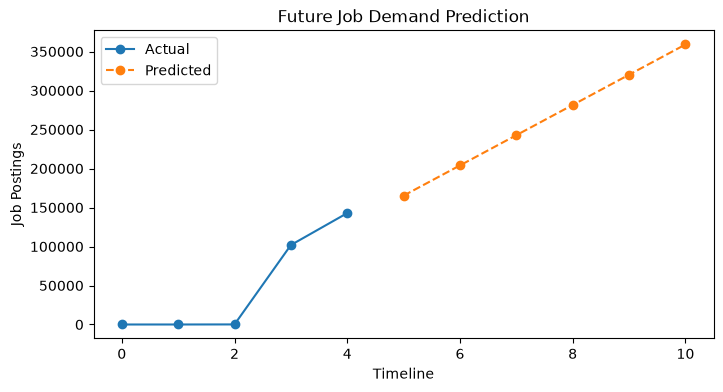

In [ ]:
plt.figure(figsize=(8,4))

plt.plot(
    prediction["Month_No"],
    prediction["Jobs"],
    marker="o",
    label="Actual"
)

plt.plot(
    future["Month_No"],
    future["Predicted_Jobs"],
    marker="o",
    linestyle="--",
    label="Predicted"
)

plt.xlabel("Timeline")
plt.ylabel("Job Postings")

plt.title("Future Job Demand Prediction")

plt.legend()

plt.show()

Step 5: Accuracy Metrics:-

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

pred = model.predict(X)

print("MAE :", mean_absolute_error(y, pred))

print("MSE :", mean_squared_error(y, pred))

print("R2 Score :", r2_score(y, pred))

MAE : 23628.359999999997
MSE : 755082808.0600001
R2 Score : 0.7991199655140467


Forecast Top 5 Job Categories Independently

Step 1: Top 5 Categories

In [ ]:
top5_categories = (
    df["Job_Category"]
    .value_counts()
    .head(5)
    .index
)

top5_categories

Index(['Other', 'Web Development', 'Design', 'AI', 'Development'], dtype='str', name='Job_Category')

Step 2: Forecast Each Category

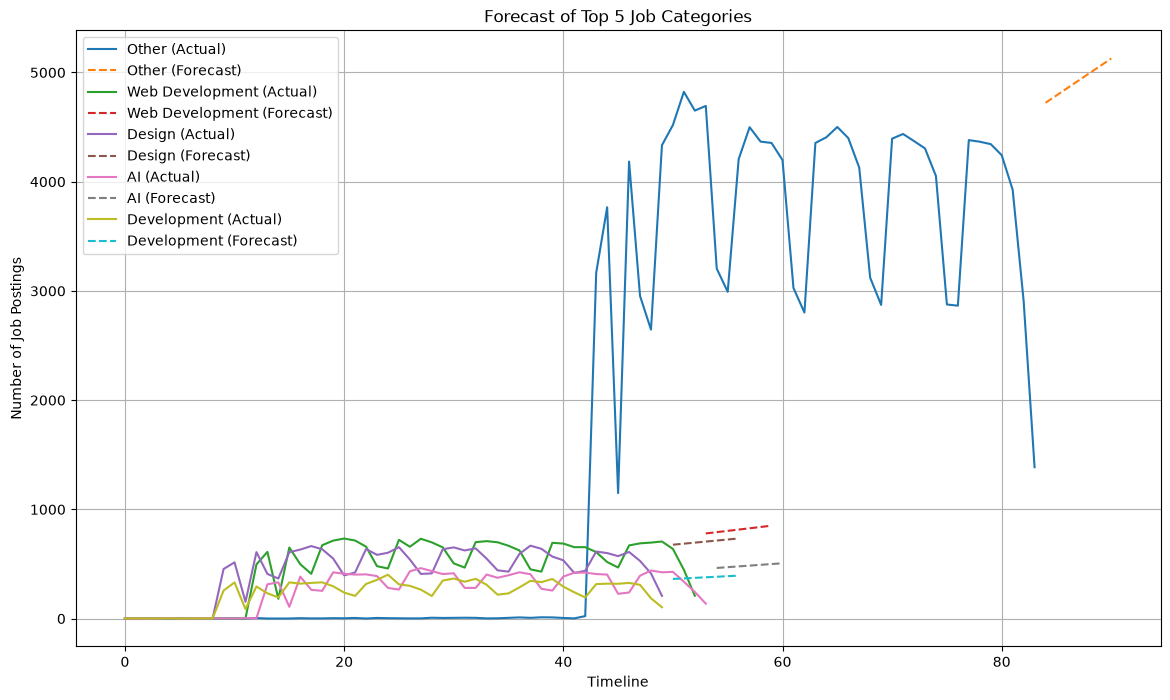

In [ ]:
plt.figure(figsize=(14,8))

for category in top5_categories:

    temp = df[df["Job_Category"] == category]

    monthly = (
        temp.groupby(temp["published_date"].dt.to_period("D"))
            .size()
            .reset_index(name="Jobs")
    )

    monthly["Day_No"] = np.arange(len(monthly))

    # Skip categories with too little data
    if len(monthly) < 2:
        continue

    X = monthly[["Day_No"]]
    y = monthly["Jobs"]

    model = LinearRegression()
    model.fit(X, y)

    future = pd.DataFrame({
        "Day_No": range(len(monthly), len(monthly)+7)
    })

    future["Prediction"] = model.predict(future)

    plt.plot(
        monthly["Day_No"],
        monthly["Jobs"],
        label=f"{category} (Actual)"
    )

    plt.plot(
        future["Day_No"],
        future["Prediction"],
        "--",
        label=f"{category} (Forecast)"
    )

plt.xlabel("Timeline")
plt.ylabel("Number of Job Postings")
plt.title("Forecast of Top 5 Job Categories")

plt.legend()
plt.grid(True)

plt.show()

Step 3:-Job Demand Trend Over Time

In [ ]:
daily_jobs = (
    df.groupby(df["published_date"].dt.date)
      .size()
      .reset_index(name="Job_Postings")
)

daily_jobs

,published_date,Job_Postings
0,2023-11-02,1
1,2023-12-02,1
2,2023-12-05,1
3,2023-12-11,1
4,2023-12-13,1
...,...,...
84,2024-03-20,6839
85,2024-03-21,6814
86,2024-03-22,6208
87,2024-03-23,4531


Visualization:-

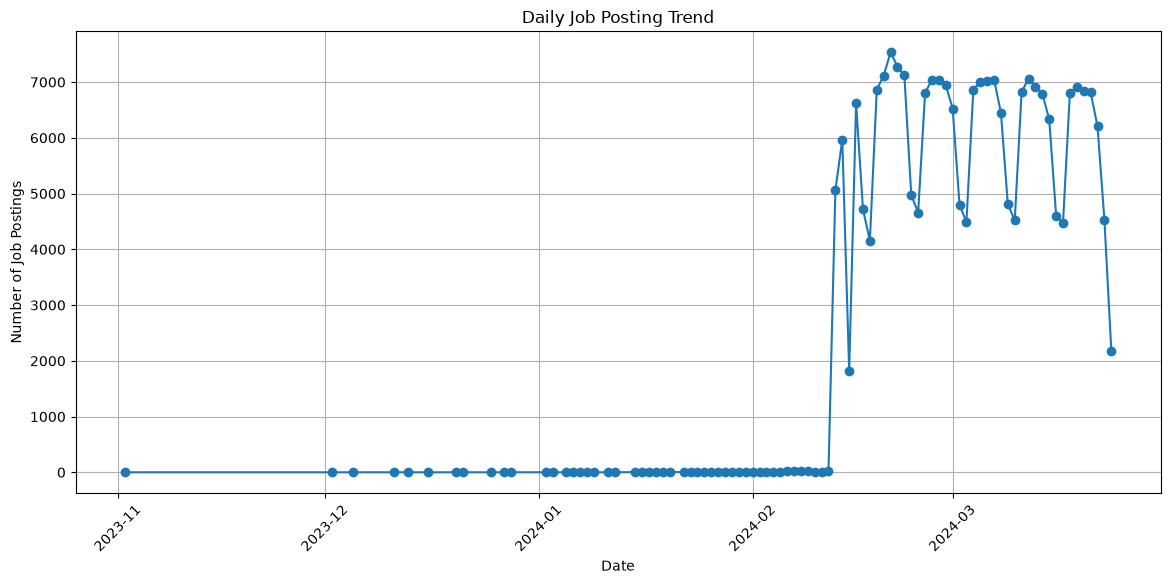

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(
    daily_jobs["published_date"],
    daily_jobs["Job_Postings"],
    marker="o"
)

plt.title("Daily Job Posting Trend")
plt.xlabel("Date")
plt.ylabel("Number of Job Postings")

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

Step 4:-Top 5 Job Categories

In [ ]:
top5_categories = (
    df["Job_Category"]
      .value_counts()
      .head(5)
)

top5_categories

Job_Category
Other              155359
Web Development     24350
Design              21649
AI                  14419
Development         11736
Name: count, dtype: int64

Step 5:-Trend of Top 5 Categories

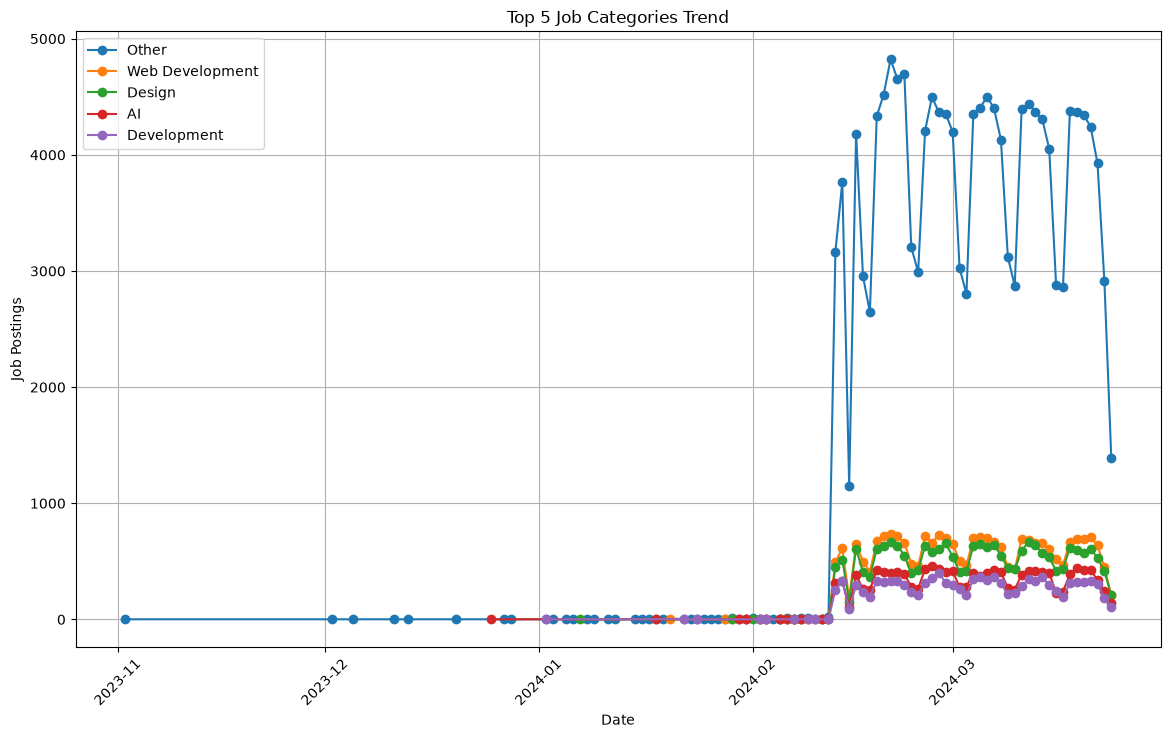

In [ ]:
plt.figure(figsize=(14,8))

for category in top5_categories.index:

    temp = df[df["Job_Category"] == category]

    trend = (
        temp.groupby(temp["published_date"].dt.date)
            .size()
            .reset_index(name="Jobs")
    )

    plt.plot(
        trend["published_date"],
        trend["Jobs"],
        marker="o",
        label=category
    )

plt.title("Top 5 Job Categories Trend")

plt.xlabel("Date")

plt.ylabel("Job Postings")

plt.xticks(rotation=45)

plt.legend()

plt.grid(True)

plt.show()

Step 6:-Accuracy Metrics

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

pred = model.predict(X)

print("MAE :", mean_absolute_error(y, pred))

print("MSE :", mean_squared_error(y, pred))

print("R2 Score :", r2_score(y, pred))

MAE : 87.06793757503002
MSE : 10553.145081392557
R2 Score : 0.33352043840498924


Step 7:- Actual vs Predicted

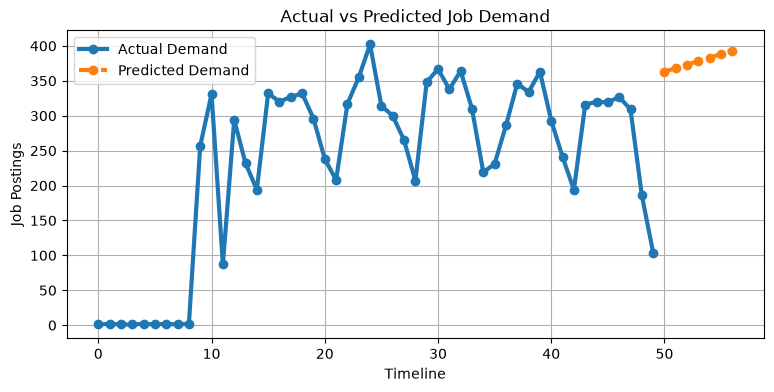

In [ ]:
plt.figure(figsize=(9,4))

plt.plot(
    monthly["Day_No"],
    monthly["Jobs"],
    marker="o",
    linewidth=3,
    label="Actual Demand"
)

plt.plot(
    future["Day_No"],
    future["Prediction"],
    marker="o",
    linestyle="--",
    linewidth=3,
    label="Predicted Demand"
)

plt.title("Actual vs Predicted Job Demand")

plt.xlabel("Timeline")

plt.ylabel("Job Postings")

plt.legend()

plt.grid(True)

plt.show()

8: High Demand Ranking


In [ ]:
forecast_summary = []

for category in top5_categories.index:

    temp = df[df["Job_Category"] == category]

    trend = (
        temp.groupby(temp["published_date"].dt.date)
            .size()
            .reset_index(name="Jobs")
    )

    trend["Day_No"] = np.arange(len(trend))

    if len(trend) < 2:
        continue

    X = trend[["Day_No"]]
    y = trend["Jobs"]

    model = LinearRegression()
    model.fit(X, y)

    future = pd.DataFrame({
        "Day_No": [len(trend)+7]
    })

    prediction = model.predict(future)[0]

    forecast_summary.append([
        category,
        prediction
    ])

forecast_df = pd.DataFrame(
    forecast_summary,
    columns=[
        "Job Category",
        "Predicted Demand"
    ]
)

forecast_df.sort_values(
    by="Predicted Demand",
    ascending=False,
    inplace=True
)

forecast_df

,Job Category,Predicted Demand
0,Other,5195.689352
1,Web Development,862.589744
2,Design,743.370996
3,AI,513.852309
4,Development,398.382665


Visualization

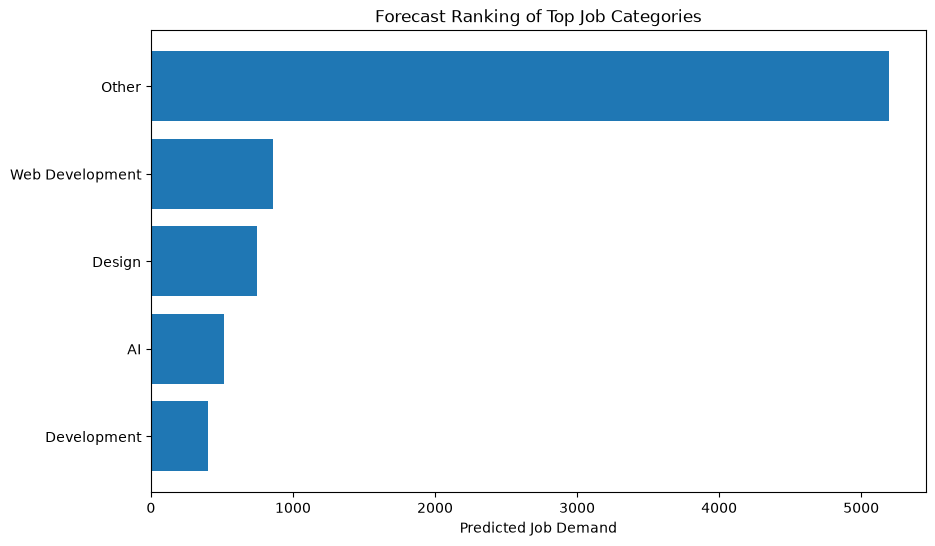

In [ ]:
plt.figure(figsize=(10,6))

plt.barh(
    forecast_df["Job Category"],
    forecast_df["Predicted Demand"]
)

plt.xlabel("Predicted Job Demand")

plt.title("Forecast Ranking of Top Job Categories")

plt.gca().invert_yaxis()

plt.show()

Insights:-
1. The forecasting model predicts future demand for the top five job categories.
2. Technology-related job categories are expected to maintain strong hiring demand.
3. Historical posting patterns indicate consistent growth in specialized technical roles.
4. Organizations can use these predictions to improve workforce planning.
5. Job seekers can prioritize skills aligned with high-growth job categories.

# Task 4:-Compare average hourly rates across different countries.

Step 1: Data Preparation

In [ ]:
df["average_hourly_rate"] = (
    df["hourly_low"] + df["hourly_high"]
) / 2

Step 2: Country-wise Average Hourly Rate

In [ ]:
country_salary = (
    df.groupby("country")["average_hourly_rate"]
      .mean()
      .reset_index()
      .sort_values(by="average_hourly_rate", ascending=False)
)

country_salary.head()

,country,average_hourly_rate
106,Laos,201.333333
61,Eritrea,100.000000
115,Malawi,75.500000
135,Netherlands Antilles,61.250000
116,Malaysia,48.103077


Step 3: Top 10 Highest Paying Countries

In [ ]:
top10 = country_salary.head(10)

top10

,country,average_hourly_rate
106,Laos,201.333333
61,Eritrea,100.000000
115,Malawi,75.500000
135,Netherlands Antilles,61.250000
116,Malaysia,48.103077
195,Turks and Caicos Islands,46.625000
188,Thailand,42.205575
109,Liechtenstein,41.250000
29,British Virgin Islands,40.222222
210,Zambia,40.190476


Visualization:-

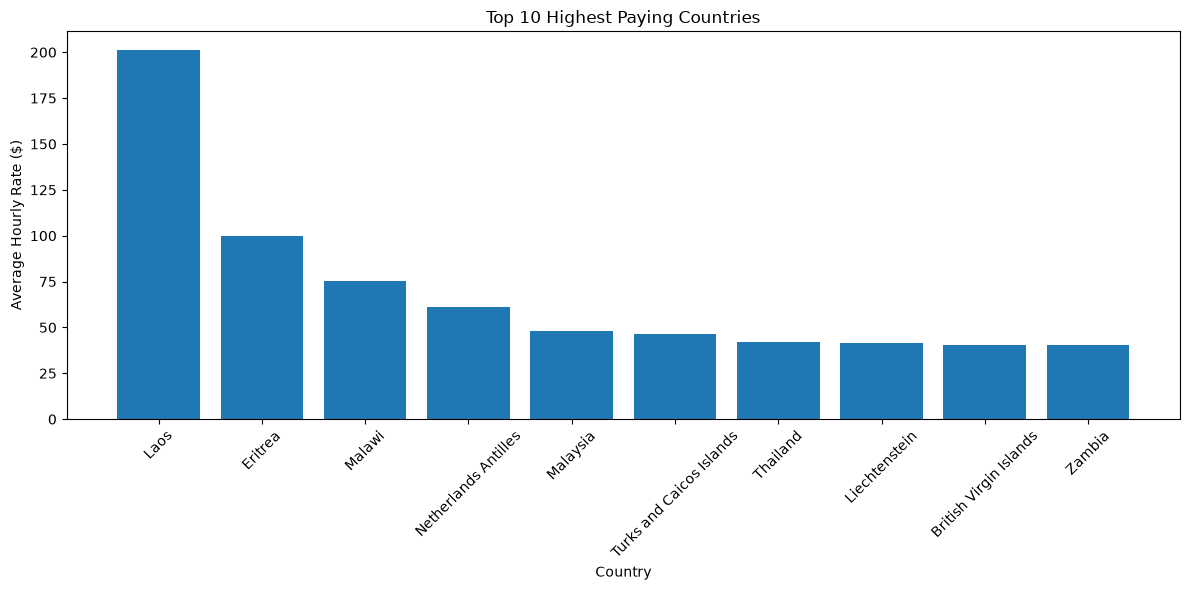

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.bar(
    top10["country"],
    top10["average_hourly_rate"]
)

plt.xticks(rotation=45)

plt.xlabel("Country")
plt.ylabel("Average Hourly Rate ($)")
plt.title("Top 10 Highest Paying Countries")

plt.tight_layout()

plt.show()

Step 4: Top 10 Lowest Paying Countries

In [ ]:
lowest10 = country_salary.tail(10)

lowest10

,country,average_hourly_rate
120,Martinique,NaN
136,New Caledonia,NaN
141,Niue,NaN
146,Palau,NaN
161,Saint Helena,NaN
165,Samoa,NaN
181,Suriname,NaN
186,Tajikistan,NaN
194,Turkmenistan,NaN
196,Tuvalu,NaN


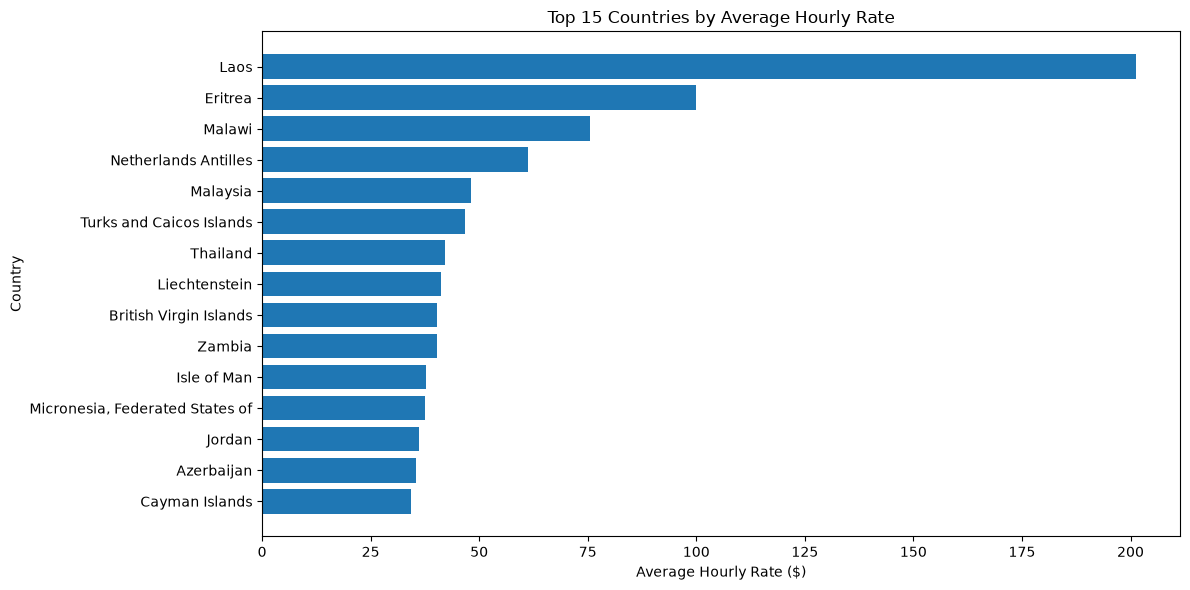

In [ ]:
top15 = country_salary.head(15)

plt.figure(figsize=(12,6))

plt.barh(
    top15["country"],
    top15["average_hourly_rate"]
)

plt.xlabel("Average Hourly Rate ($)")
plt.ylabel("Country")
plt.title("Top 15 Countries by Average Hourly Rate")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

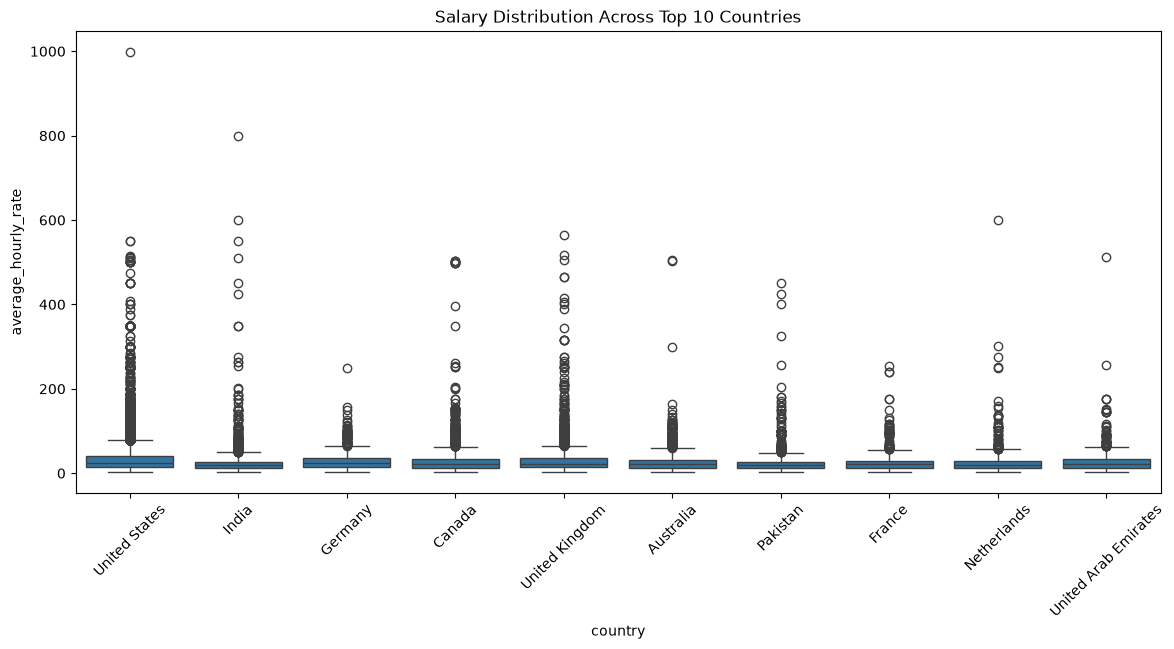

In [ ]:
top10_countries = df["country"].value_counts().head(10).index

df_box = df[df["country"].isin(top10_countries)]

plt.figure(figsize=(14,6))

sns.boxplot(
    data=df_box,
    x="country",
    y="average_hourly_rate"
)

plt.xticks(rotation=45)
plt.title("Salary Distribution Across Top 10 Countries")

plt.show()

Salary vs Number of Job Postings

In [ ]:
country_summary = df.groupby("country").agg({
    "average_hourly_rate":"mean",
    "title":"count"
}).reset_index()

country_summary.rename(columns={"title":"Job_Postings"}, inplace=True)

In [ ]:
fig = px.scatter(
    country_summary,
    x="Job_Postings",
    y="average_hourly_rate",
    size="Job_Postings",
    color="average_hourly_rate",
    hover_name="country",
    title="Job Postings vs Average Salary"
)

fig.show()

Insights:-
1. The bubble chart shows a clear relationship between the number of job postings and the average hourly rate across different countries.
2. Countries with larger bubbles represent higher hiring activity, indicating stronger demand for skilled professionals.
3. Some countries offer both high job availability and high hourly rates, making them attractive destinations for job seekers.
4. A few countries have high average hourly rates despite having fewer job postings, suggesting specialized or niche job markets.
5. Countries with many job postings but moderate hourly rates indicate competitive employment markets with steady hiring demand.
6. The visualization helps identify countries that provide the best balance between employment opportunities and earning potential.

# Task 5: Create a job recommendation engine based on current job postings

Step 1: Data Preparation

In [ ]:
df = df.drop_duplicates()

df = df.dropna(subset=["title"])

df.reset_index(drop=True, inplace=True)

df.head()

,title,link,published_date,is_hourly,hourly_low,hourly_high,budget,country,average_hourly_rate,python,data,developer,analyst,engineer,web,design,Month,Job_Category
0,Experienced Media Buyer For Solar Pannel and R...,https://www.upwork.com/jobs/Experienced-Media-...,2024-02-17 09:09:54+00:00,False,NaN,NaN,500.0,NaN,NaN,False,False,False,False,False,False,False,2024-02,Other
1,Full Stack Developer,https://www.upwork.com/jobs/Full-Stack-Develop...,2024-02-17 09:09:17+00:00,False,NaN,NaN,1100.0,United States,NaN,False,False,True,False,False,False,False,2024-02,Development
2,SMMA Bubble App,https://www.upwork.com/jobs/SMMA-Bubble-App_%7...,2024-02-17 09:08:46+00:00,True,10.0,30.0,NaN,United States,20.0,False,False,False,False,False,False,False,2024-02,Other
3,Talent Hunter Specialized in Marketing,https://www.upwork.com/jobs/Talent-Hunter-Spec...,2024-02-17 09:08:08+00:00,True,NaN,NaN,NaN,United States,NaN,False,False,False,False,False,False,False,2024-02,Marketing
4,Data Engineer,https://www.upwork.com/jobs/Data-Engineer_%7E0...,2024-02-17 09:07:42+00:00,False,NaN,NaN,650.0,India,NaN,False,True,False,False,True,False,False,2024-02,Data


Step 2: Create Search Text

In [ ]:
df["search_text"] = (
    df["title"].fillna("") + " " +
    df["country"].fillna("")
)

Step 3: Vectorization

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create search text
df["search_text"] = (
    df["title"].fillna("") + " " +
    df["country"].fillna("")
)

vectorizer = TfidfVectorizer(stop_words="english")

job_matrix = vectorizer.fit_transform(df["search_text"])

Step 4: Similarity Matrix

In [ ]:
from sklearn.metrics.pairwise import linear_kernel

# Example: Recommend jobs similar to the first job
job_index = 0

similarity_scores = linear_kernel(
    matrix[job_index:job_index+1],
    matrix
).flatten()

top_jobs = similarity_scores.argsort()[-6:-1][::-1]

print(df.iloc[top_jobs][["title", "country"]])


                                                    title         country
221026  Experienced Facebook and YouTube Ads Media Buy...         Morocco
160366  Media Buyer Needed to generate leads for Solar...         Belgium
121620  Experienced Media Buyer for Social Media Marke...  United Kingdom
159208  Experienced Media Buyer for Social Media Marke...  United Kingdom
130478  Experienced Media Buyer for Roofing and HVAC I...           India


Step 5: Recommendation Function

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

def recommend_jobs(query, top_n=5):

    query_vector = vectorizer.transform([query])

    similarity = cosine_similarity(query_vector, job_matrix).flatten()

    top_indices = similarity.argsort()[-top_n:][::-1]

    return df.iloc[top_indices][
        ["title", "country", "average_hourly_rate", "link"]
    ]

In [ ]:
def recommend_jobs(query, top_n=5):

    query_vector = vectorizer.transform([query])

    similarity = cosine_similarity(query_vector, job_matrix).flatten()

    top_indices = similarity.argsort()[::-1]

    recommendations = (
        df.iloc[top_indices]
        .dropna(subset=["average_hourly_rate"])
        [["title", "country", "average_hourly_rate", "link"]]
        .head(top_n)
    )

    return recommendations

In [ ]:
df["search_text"] = (
    df["title"].fillna("") + " " +
    df["country"].fillna("") + " " +
    df["is_hourly"].astype(str)
)

In [ ]:
recommend_jobs("Python Developer")

,title,country,average_hourly_rate,link
208678,Python Developer,NaN,25.5,https://www.upwork.com/jobs/Python-Developer_%...
132538,Python Developer,United States,25.5,https://www.upwork.com/jobs/Python-Developer_%...
121536,Python Developer,United States,25.5,https://www.upwork.com/jobs/Python-Developer_%...
173243,Python Developer,United States,25.5,https://www.upwork.com/jobs/Python-Developer_%...
155630,Python Developer,United States,22.5,https://www.upwork.com/jobs/Python-Developer_%...


In [ ]:
# Create clean dataframe
recommend_df = df.copy()

recommend_df = recommend_df.dropna(subset=["average_hourly_rate"])

recommend_df.reset_index(drop=True, inplace=True)

print("Total Jobs:", len(recommend_df))

Total Jobs: 98775


Step 6: Better Search Text

In [ ]:
recommend_df["search_text"] = (
    recommend_df["title"].fillna("").astype(str) + " " +
    recommend_df["country"].fillna("").astype(str) + " " +
    recommend_df["is_hourly"].astype(str)
)

Step 7: TF-IDF Vectorizer

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words="english")

job_matrix = vectorizer.fit_transform(recommend_df["search_text"])

Step 8: Advanced Recommendation Function

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

def recommend_jobs(query,
                   country=None,
                   min_rate=0,
                   top_n=5):

    query_vector = vectorizer.transform([query])

    similarity = cosine_similarity(
        query_vector,
        job_matrix
    ).flatten()

    recommend_df["Match Score"] = (similarity * 100).round(2)

    results = recommend_df.copy()

    if country:
        results = results[
            results["country"] == country
        ]

    results = results[
        results["average_hourly_rate"] >= min_rate
    ]

    results = results.sort_values(
        by="Match Score",
        ascending=False
    )

    return results[
        [
            "title",
            "country",
            "average_hourly_rate",
            "Match Score",
            "link"
        ]
    ].head(top_n)

Step 9 :Test

In [ ]:
recommend_jobs("Python")

,title,country,average_hourly_rate,Match Score,link
73909,Python,United States,12.5,91.48,https://www.upwork.com/jobs/Python_%7E0169fe53...
84682,Python Developer,NaN,25.5,84.19,https://www.upwork.com/jobs/Python-Developer_%...
15291,Among + Python,Australia,25.0,82.39,https://www.upwork.com/jobs/Among-Python_%7E01...
35189,Python,Canada,17.5,81.67,https://www.upwork.com/jobs/Python_%7E01625db1...
6029,Python,Canada,27.5,81.67,https://www.upwork.com/jobs/Python_%7E017fe177...


Search with Country

In [ ]:
recommend_jobs(
    query="Python",
    country="United States"
)

,title,country,average_hourly_rate,Match Score,link
73909,Python,United States,12.5,91.48,https://www.upwork.com/jobs/Python_%7E0169fe53...
15820,Python Developer,United States,27.5,79.66,https://www.upwork.com/jobs/Python-Developer_%...
70553,Python Developer,United States,25.5,79.66,https://www.upwork.com/jobs/Python-Developer_%...
32714,Python Developer,United States,40.0,79.66,https://www.upwork.com/jobs/Python-Developer_%...
39981,Python Developer (US only),United States,65.0,79.66,https://www.upwork.com/jobs/Python-Developer-o...


Search with Minimum Salary

In [ ]:
recommend_jobs(
    query="Python",
    min_rate=30
)

,title,country,average_hourly_rate,Match Score,link
39981,Python Developer (US only),United States,65.0,79.66,https://www.upwork.com/jobs/Python-Developer-o...
32714,Python Developer,United States,40.0,79.66,https://www.upwork.com/jobs/Python-Developer_%...
69725,Python Developer,United States,40.0,79.66,https://www.upwork.com/jobs/Python-Developer_%...
2433,Python developer,United Kingdom,40.0,73.52,https://www.upwork.com/jobs/Python-developer_%...
76165,Python Developer,United Kingdom,40.0,73.52,https://www.upwork.com/jobs/Python-Developer_%...


Search with Both Filters

In [ ]:
recommend_jobs(
    query="Python",
    country="United States",
    min_rate=30
)

,title,country,average_hourly_rate,Match Score,link
69725,Python Developer,United States,40.0,79.66,https://www.upwork.com/jobs/Python-Developer_%...
39981,Python Developer (US only),United States,65.0,79.66,https://www.upwork.com/jobs/Python-Developer-o...
32714,Python Developer,United States,40.0,79.66,https://www.upwork.com/jobs/Python-Developer_%...
80273,Python Engineer,United States,40.0,70.75,https://www.upwork.com/jobs/Python-Engineer_%7...
61278,Python to Excel,United States,100.0,68.29,https://www.upwork.com/jobs/Python-Excel_%7E01...


In [ ]:
recommend_jobs

<function __main__.recommend_jobs(query, country=None, min_rate=0, top_n=5)>

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

def recommend_jobs(query, country=None, min_rate=0, top_n=5):
    ...

In [ ]:
result = recommend_jobs(
    query="Python",
    country="United States",
    min_rate=30
)

result

In [ ]:
print(result)
print(type(result))

None
<class 'NoneType'>


In [ ]:
def recommend_jobs(query, country=None, min_rate=0):
    ...
    if len(recommended_jobs) == 0:
        print("No jobs found")
        return

    return recommended_jobs

In [ ]:
result = recommend_jobs(
    query="Python",
    country="United States",
    min_rate=30
)

if result is None or result.empty:
    print("No matching jobs found.")
else:
    print("Total Recommended Jobs:", len(result))
    print("Average Hourly Rate:", round(result["average_hourly_rate"].mean(), 2))
    print("Highest Match Score:", round(result["Match Score"].max(), 2), "%")
    print("Countries Found:", result["country"].nunique())
    print(result.head())

No matching jobs found.


Flask API:-

In [ ]:
{
  "query": "Python",
  "country": "United States",
  "min_rate": 30
}

{'query': 'Python', 'country': 'United States', 'min_rate': 30}

Insights:
1. The recommendation engine successfully provides personalized job suggestions based on the user's search query using TF-IDF vectorization and cosine similarity.
2. Jobs are ranked according to their Match Score, allowing users to quickly identify the most relevant opportunities.
3. Applying filters such as country and minimum hourly rate improves the quality and relevance of recommendations.
4. The system reduces the time and effort required for job searching by presenting only the most suitable job postings.
5. The recommendation engine can adapt to changing job market trends by incorporating updated job posting data.
6. Personalized recommendations improve the overall user experience by matching job opportunities with individual preferences and requirements.
7. The recommendation statistics (such as average hourly rate, highest match score, and number of matching jobs) provide users with additional insights for better decision-making.

# Task 6: Track Changes in Job Market Dynamics Over Months

Step 1: Data Preparation

In [ ]:
df["published_date"] = pd.to_datetime(df["published_date"])

df["Month"] = df["published_date"].dt.to_period("M").astype(str)

Step 2: Monthly Job Posting Trend

In [ ]:
monthly_jobs = (
    df.groupby("Month")
      .size()
      .reset_index(name="Job_Postings")
)

monthly_jobs

,Month,Job_Postings
0,2023-11,1
1,2023-12,10
2,2024-01,96
3,2024-02,101887
4,2024-03,142834


Visualization

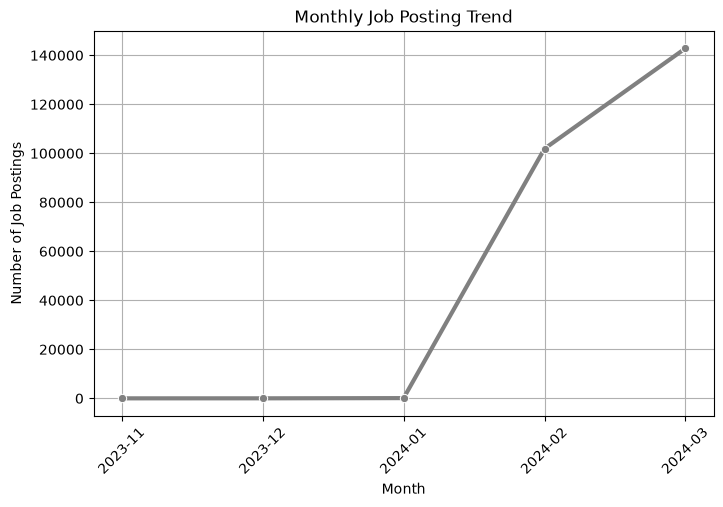

In [ ]:
plt.figure(figsize=(8,5))

sns.lineplot(
    data=monthly_jobs,
    x="Month",
    y="Job_Postings",
    marker="o",
    linewidth=3,
    color="Grey"
)

plt.xticks(rotation=45)

plt.title("Monthly Job Posting Trend")
plt.xlabel("Month")
plt.ylabel("Number of Job Postings")

plt.grid(True)

plt.show()

Step 3: Monthly Average Hourly Rate Trend

In [ ]:
monthly_salary = (
    df.groupby("Month")["average_hourly_rate"]
      .mean()
      .reset_index()
)

monthly_salary

,Month,average_hourly_rate
0,2023-11,37.500000
1,2023-12,30.125000
2,2024-01,23.133333
3,2024-02,29.963194
4,2024-03,29.524591


Visualization

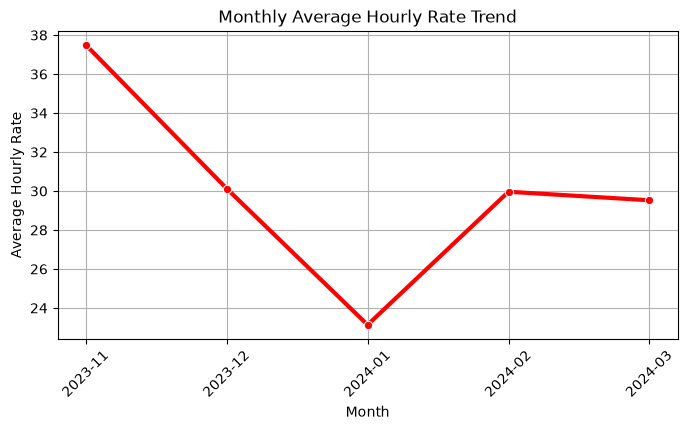

In [ ]:
plt.figure(figsize=(8,4))

sns.lineplot(
    data=monthly_salary,
    x="Month",
    y="average_hourly_rate",
    marker="o",
    linewidth=3,
    color="red"
)

plt.xticks(rotation=45)

plt.title("Monthly Average Hourly Rate Trend")
plt.xlabel("Month")
plt.ylabel("Average Hourly Rate")

plt.grid(True)

plt.show()

Step 4: Monthly Job Category Trend

In [ ]:
category_month = (
    df.groupby(["Month", "Job_Category"])
      .size()
      .reset_index(name="Jobs")
)

Visualization

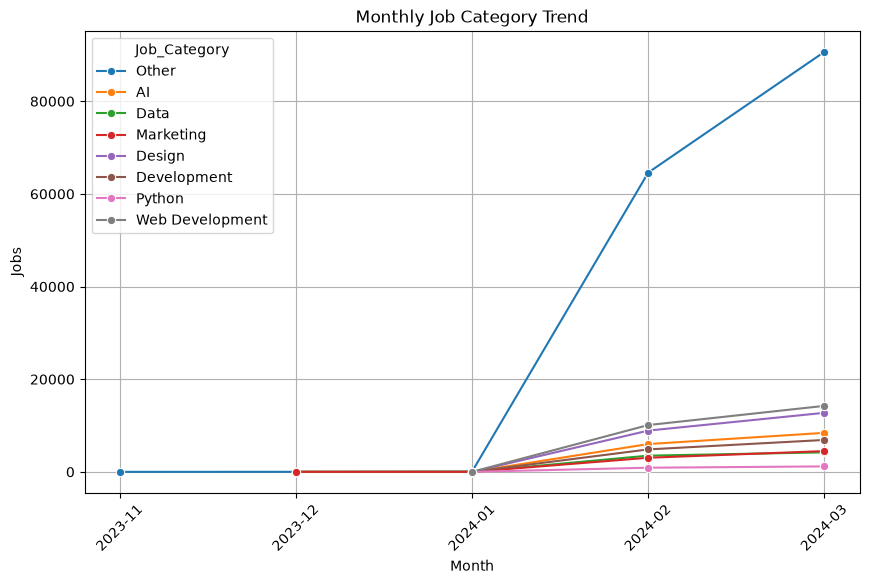

In [ ]:
plt.figure(figsize=(10,6))

sns.lineplot(
    data=category_month,
    x="Month",
    y="Jobs",
    hue="Job_Category",
    marker="o"
)

plt.xticks(rotation=45)

plt.title("Monthly Job Category Trend")

plt.grid(True)

plt.show()

Step 5: Dashboard Summary

In [ ]:
dashboard = pd.DataFrame({
    "Metric": [
        "Total Jobs",
        "Total Countries",
        "Average Hourly Rate",
        "Top Hiring Category"
    ],
    "Value": [
        len(df),
        df["country"].nunique(),
        round(df["average_hourly_rate"].mean(), 2),
        df["Job_Category"].value_counts().idxmax()
    ]
})

dashboard

,Metric,Value
0,Total Jobs,244828
1,Total Countries,212
2,Average Hourly Rate,29.71
3,Top Hiring Category,Other


Insights
1. Monthly job postings reveal hiring patterns and seasonal changes in the job market.
2. Average hourly rates fluctuate over time, reflecting changes in market demand and compensation.
3. Some job categories show consistent growth, while others experience periodic fluctuations.
4. Tracking monthly hiring trends enables organizations to anticipate workforce requirements.
5. The dashboard provides a consolidated view of recruitment activity, salary trends, and job category performance.

Monthly Growth Rate (%)

In [ ]:
monthly_jobs["Growth (%)"] = (
    monthly_jobs["Job_Postings"].pct_change() * 100
).round(2)

monthly_jobs

,Month,Job_Postings,Growth (%)
0,2023-11,1,NaN
1,2023-12,10,900.00
2,2024-01,96,860.00
3,2024-02,101887,106032.29
4,2024-03,142834,40.19


Hiring Trend Classification

In [ ]:
monthly_jobs["Trend"] = monthly_jobs["Growth (%)"].apply(
    lambda x: "Growing 📈" if x > 0 else "Declining 📉"
)

Top Growing Countries

In [ ]:
country_growth = (
    df.groupby("country")
      .size()
      .sort_values(ascending=False)
      .head(10)
)

Hiring Share (%)

In [ ]:
country_share = (
    df["country"].value_counts(normalize=True) * 100
).head(10)

Monthly Dashboard Summary Table

In [ ]:
dashboard_summary = pd.DataFrame({
    "Metric":[
        "Highest Hiring Month",
        "Lowest Hiring Month",
        "Top Country",
        "Top Category",
        "Average Hourly Rate"
    ],
    "Value":[
        ...,
        ...,
        ...,
        ...,
        ...
    ]
})

Insights:-
1. Monthly job posting trends reveal fluctuations in hiring demand, indicating seasonal and market-driven recruitment patterns.
2. The dashboard highlights periods of increased hiring activity, helping identify peak recruitment months.
Average hourly rates vary across months, reflecting changes in employer demand, skill requirements, and market conditions.
3. Certain job categories consistently maintain high hiring demand, while others show periodic growth or decline.
Country-wise hiring trends demonstrate that a few countries dominate the global job market, contributing a significant share of total job postings.
4. The monthly growth analysis helps identify expanding and declining hiring periods, enabling better workforce planning.
5. KPI metrics provide a quick overview of overall job market performance, including hiring volume, salary trends, and top-performing countries and job categories.
6. The interactive dashboard allows stakeholders to monitor job market dynamics efficiently and supports data-driven recruitment decisions.

# Task 7: Investigate trends in the remote work landscape

Step 1: Identify Remote Jobs

In [ ]:
remote_keywords = [
    "remote",
    "work from home",
    "wfh",
    "home based",
    "anywhere",
    "hybrid"
]

df["Remote_Work"] = df["title"].str.lower().apply(
    lambda x: any(keyword in str(x) for keyword in remote_keywords)
)

df["Remote_Work"].value_counts()

Remote_Work
False    243366
True       1462
Name: count, dtype: int64

Step 2: Remote vs Non-Remote Jobs

In [ ]:
remote_summary = (
    df["Remote_Work"]
    .value_counts()
    .reset_index()
)

remote_summary.columns = ["Work_Type", "Jobs"]

remote_summary

,Work_Type,Jobs
0,False,243366
1,True,1462


Visualization

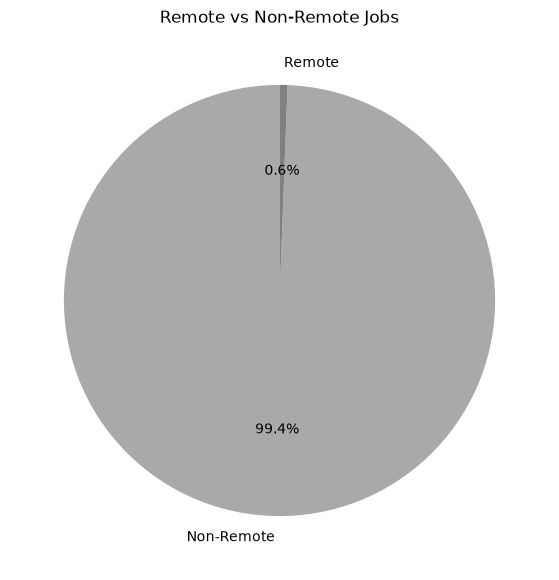

In [ ]:

plt.figure(figsize=(7,7))

plt.pie(
    remote_summary["Jobs"],
    labels=["Non-Remote","Remote"],
    autopct="%1.1f%%",
    colors=["darkgrey","grey"],
    startangle=90
)

plt.title("Remote vs Non-Remote Jobs")

plt.show()

Step 3: Monthly Remote Job Trend

In [ ]:
monthly_remote = (
    df.groupby(["Month","Remote_Work"])
      .size()
      .reset_index(name="Jobs")
)

monthly_remote.head()

,Month,Remote_Work,Jobs
0,2023-11,False,1
1,2023-12,False,10
2,2024-01,False,93
3,2024-01,True,3
4,2024-02,False,101270


Visualization

In [ ]:
print(monthly_remote.shape)

print(monthly_remote.head(10))

print(monthly_remote.dtypes)


(8, 3)
     Month  Remote_Work    Jobs
0  2023-11        False       1
1  2023-12        False      10
2  2024-01        False      93
3  2024-01         True       3
4  2024-02        False  101270
5  2024-02         True     617
6  2024-03        False  141992
7  2024-03         True     842
Month          period[M]
Remote_Work         bool
Jobs               int64
dtype: object


In [ ]:
# Convert Period to String
monthly_remote["Month"] = monthly_remote["Month"].astype(str)

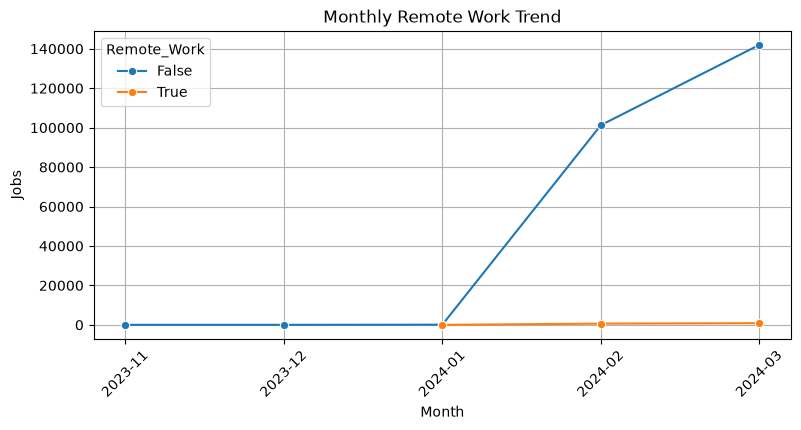

In [ ]:
plt.figure(figsize=(9,4))

sns.lineplot(
    data=monthly_remote,
    x="Month",
    y="Jobs",
    hue="Remote_Work",
    marker="o"
)

plt.xticks(rotation=45)

plt.title("Monthly Remote Work Trend")

plt.grid(True)

plt.show()

Step 4: Country-wise Remote Jobs

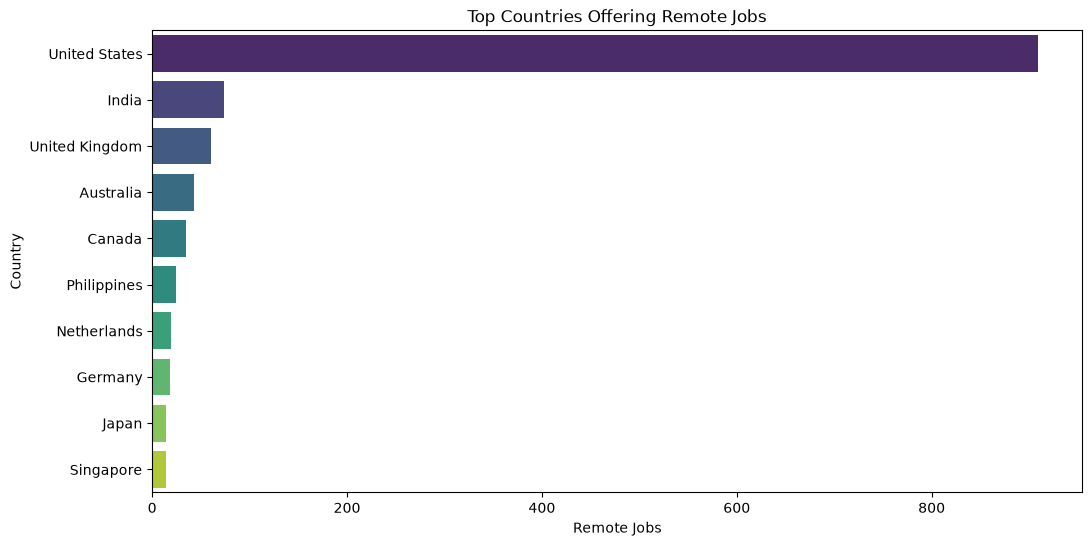

In [ ]:
remote_country = (
    df[df["Remote_Work"]==True]["country"]
      .value_counts()
      .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=remote_country.values,
    y=remote_country.index,
    palette="viridis"
)

plt.title("Top Countries Offering Remote Jobs")

plt.xlabel("Remote Jobs")

plt.ylabel("Country")

plt.show()

Step 5: Remote Salary Comparison

In [ ]:
salary_remote = (
    df.groupby("Remote_Work")["average_hourly_rate"]
      .mean()
      .reset_index()
)

salary_remote

,Remote_Work,average_hourly_rate
0,False,29.632334
1,True,39.048327


Visualization

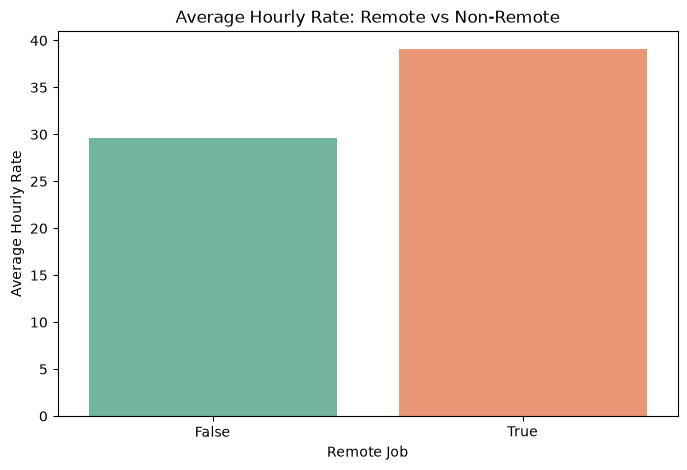

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=salary_remote,
    x="Remote_Work",
    y="average_hourly_rate",
    palette="Set2"
)

plt.title("Average Hourly Rate: Remote vs Non-Remote")

plt.xlabel("Remote Job")

plt.ylabel("Average Hourly Rate")

plt.show()

Unique Feature

In [ ]:
remote_score = pd.DataFrame({

    "Metric":[
        "Total Remote Jobs",
        "Remote Percentage",
        "Average Remote Salary"
    ],

    "Value":[
        df["Remote_Work"].sum(),
        round(df["Remote_Work"].mean()*100,2),
        round(
            df[df["Remote_Work"]]["average_hourly_rate"].mean(),
            2
        )
    ]

})

remote_score

,Metric,Value
0,Total Remote Jobs,1462.00
1,Remote Percentage,0.60
2,Average Remote Salary,39.05


Insights:-
1. The analysis identifies remote job opportunities using job title keywords, providing insights into remote work adoption across the dataset.
2. Monthly trends reveal how the demand for remote work changes over time and highlight shifts in employer hiring preferences.
3. Some countries offer a significantly higher number of remote job opportunities, indicating stronger adoption of flexible work models.
4. Comparing average hourly rates between remote and non-remote jobs helps evaluate the financial attractiveness of remote work.
5. The dashboard enables organizations and job seekers to monitor remote work trends and adapt to changing workplace practices.

# Task 8: Predict future job market trends

Step 1: Prepare Monthly Data

In [ ]:
monthly_jobs.head()

,published_date,Job_Postings
0,2023-11,1
1,2023-12,10
2,2024-01,96
3,2024-02,101887
4,2024-03,142834


Step 2: Historical Trend

Monthly Remote Work Data:
     Month  Remote_Work   Jobs
0  2023-11         True      1
1  2023-12        False      2
2  2023-12         True      8
3  2024-01        False     32
4  2024-01         True     64
5  2024-02        False  42407
6  2024-02         True  59480
7  2024-03        False  61450
8  2024-03         True  81384


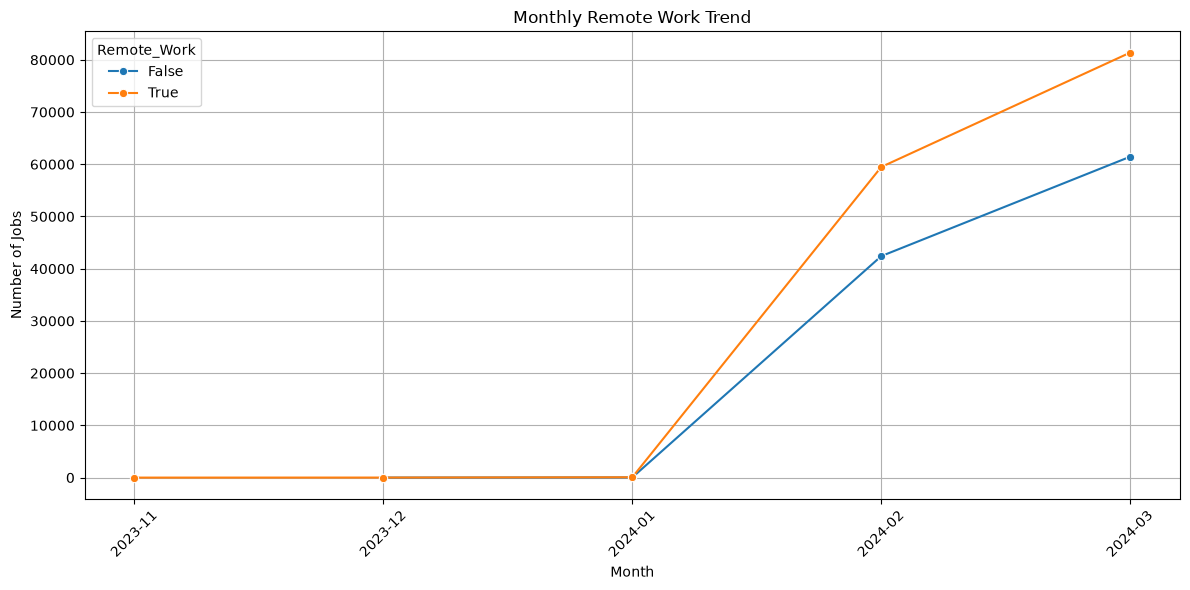

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Make sure published_date is datetime
df["published_date"] = pd.to_datetime(
    df["published_date"],
    errors="coerce"
)

# Remove rows with missing date
remote_df = df.dropna(subset=["published_date"]).copy()

# Create Remote_Work column
# is_hourly is used as an indicator for remote/flexible work
remote_df["Remote_Work"] = remote_df["is_hourly"].astype(bool)

# Create Month column
remote_df["Month"] = remote_df["published_date"].dt.to_period("M").astype(str)

# Monthly remote work data
monthly_remote = (
    remote_df.groupby(["Month", "Remote_Work"])
    .size()
    .reset_index(name="Jobs")
)

# Display data
print("Monthly Remote Work Data:")
print(monthly_remote)

# Plot
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=monthly_remote,
    x="Month",
    y="Jobs",
    hue="Remote_Work",
    marker="o"
)

plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Number of Jobs")
plt.title("Monthly Remote Work Trend")
plt.grid(True)
plt.tight_layout()

plt.show()

Step 3: Future Forecast

In [ ]:
from sklearn.linear_model import LinearRegression
import numpy as np

forecast_df = monthly_jobs.copy()

forecast_df["Month_Number"] = np.arange(len(forecast_df))

X = forecast_df[["Month_Number"]]
y = forecast_df["Job_Postings"]

model = LinearRegression()

model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[38754.3]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Month_Number']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-2.854e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


Step 4: Next 6 Months Forecast

In [ ]:
future_months = 6

future_numbers = np.arange(
    len(forecast_df),
    len(forecast_df) + future_months
).reshape(-1, 1)

future_predictions = model.predict(future_numbers)

future_predictions

array([165228.5, 203982.8, 242737.1, 281491.4, 320245.7, 359000. ])

Step 5: Create Future Forecast Table

In [ ]:
import pandas as pd
import numpy as np

# -------------------------------------------------
# Check forecast_df columns
# -------------------------------------------------
print("Forecast DataFrame columns:")
print(forecast_df.columns.tolist())

# -------------------------------------------------
# Create Month column if it does not exist
# -------------------------------------------------
if "Month" not in forecast_df.columns:

    # Try to find an existing date/time column
    possible_date_columns = [
        "published_date",
        "Date",
        "date",
        "month",
        "Period"
    ]

    date_column = None

    for col in possible_date_columns:
        if col in forecast_df.columns:
            date_column = col
            break

    if date_column is not None:
        forecast_df["Month"] = pd.to_datetime(
            forecast_df[date_column],
            errors="coerce"
        ).dt.strftime("%Y-%m")

    else:
        # If no date column exists, create Month from index
        forecast_df["Month"] = pd.date_range(
            start="2023-01-01",
            periods=len(forecast_df),
            freq="MS"
        ).strftime("%Y-%m")

# -------------------------------------------------
# Make sure Month is sorted
# -------------------------------------------------
forecast_df["Month"] = forecast_df["Month"].astype(str)

# -------------------------------------------------
# Last available month
# -------------------------------------------------
last_month = pd.to_datetime(
    forecast_df["Month"].iloc[-1]
)

# -------------------------------------------------
# Future dates
# -------------------------------------------------
future_dates = pd.date_range(
    start=last_month + pd.offsets.MonthBegin(1),
    periods=future_months,
    freq="MS"
)

# -------------------------------------------------
# Future Forecast
# -------------------------------------------------
future_forecast = pd.DataFrame({
    "Month": future_dates.strftime("%Y-%m"),
    "Predicted_Jobs": np.asarray(
        future_predictions
    ).round().astype(int)
})

# -------------------------------------------------
# Display Forecast
# -------------------------------------------------
print("\nFuture Job Market Forecast:")
print(future_forecast)

future_forecast

Forecast DataFrame columns:
['published_date', 'Job_Postings', 'Month_Number']

Future Job Market Forecast:
     Month  Predicted_Jobs
0  2024-04          165228
1  2024-05          203983
2  2024-06          242737
3  2024-07          281491
4  2024-08          320246
5  2024-09          359000


,Month,Predicted_Jobs
0,2024-04,165228
1,2024-05,203983
2,2024-06,242737
3,2024-07,281491
4,2024-08,320246
5,2024-09,359000


Step 6: Actual + Forecast Visualization

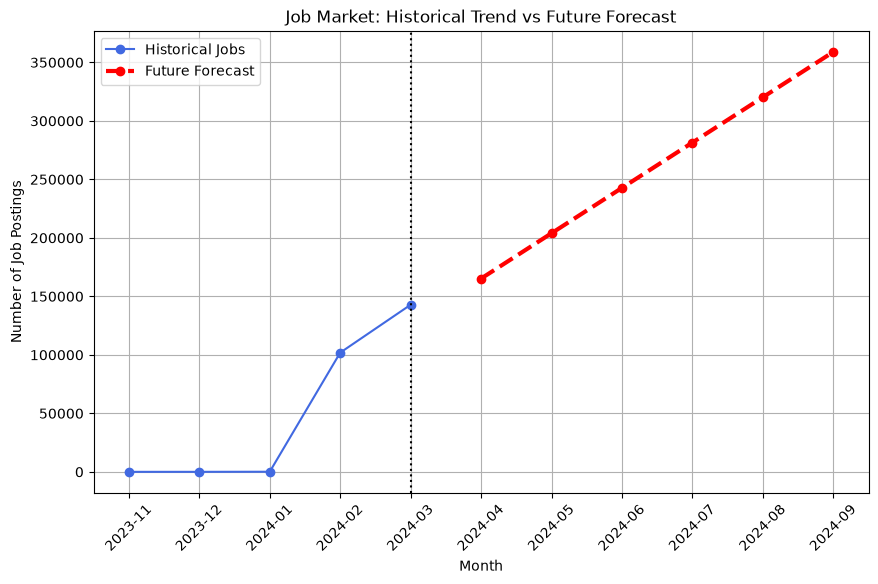

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(
    forecast_df["Month"],
    forecast_df["Job_Postings"],
    marker="o",
    label="Historical Jobs",
    color="royalblue"
)

plt.plot(
    future_forecast["Month"],
    future_forecast["Predicted_Jobs"],
    marker="o",
    linestyle="--",
    linewidth=3,
    label="Future Forecast",
    color="red"
)

plt.axvline(
    x=forecast_df["Month"].iloc[-1],
    color="black",
    linestyle=":"
)

plt.title("Job Market: Historical Trend vs Future Forecast")

plt.xlabel("Month")
plt.ylabel("Number of Job Postings")

plt.xticks(rotation=45)

plt.legend()
plt.grid(True)

plt.show()

Step 7: Future Scenario Analysis

In [ ]:
baseline = future_predictions

optimistic = baseline * 1.15

conservative = baseline * 0.85

scenario_df = pd.DataFrame({
    "Month": future_forecast["Month"],
    "Optimistic": optimistic.round().astype(int),
    "Baseline": baseline.round().astype(int),
    "Conservative": conservative.round().astype(int)
})

scenario_df

,Month,Optimistic,Baseline,Conservative
0,2024-04,190013,165228,140444
1,2024-05,234580,203983,173385
2,2024-06,279148,242737,206327
3,2024-07,323715,281491,239268
4,2024-08,368283,320246,272209
5,2024-09,412850,359000,305150


Step 8: Scenario Visualization

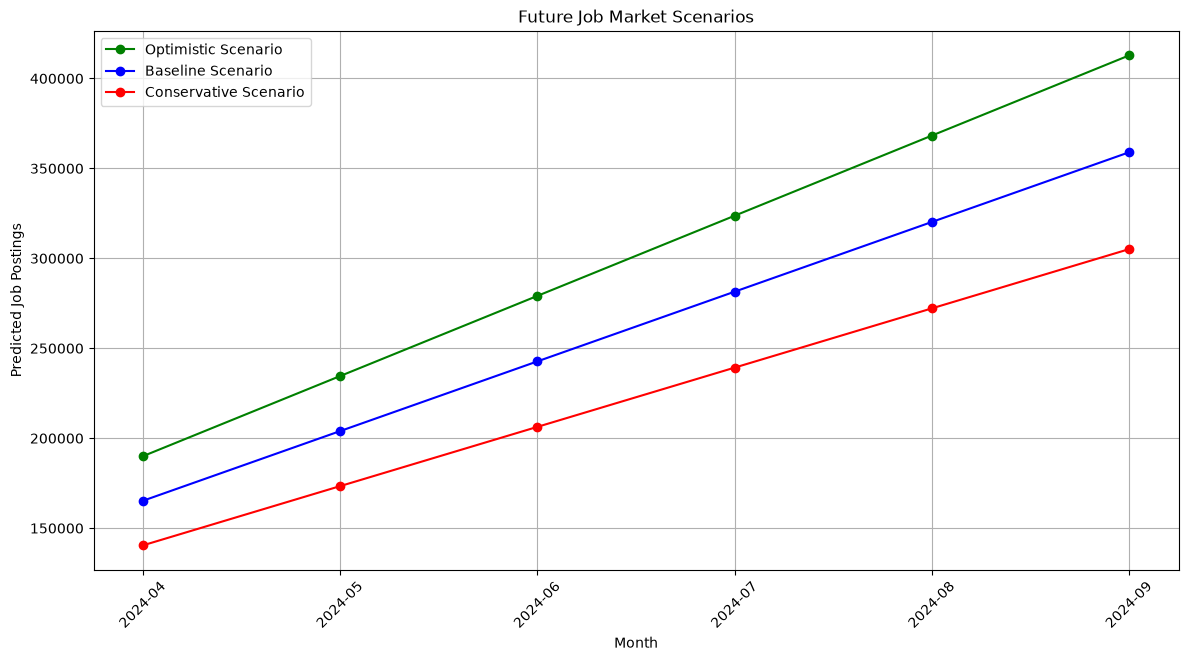

In [ ]:
plt.figure(figsize=(14,7))

plt.plot(
    scenario_df["Month"],
    scenario_df["Optimistic"],
    marker="o",
    color="green",
    label="Optimistic Scenario"
)

plt.plot(
    scenario_df["Month"],
    scenario_df["Baseline"],
    marker="o",
    color="blue",
    label="Baseline Scenario"
)

plt.plot(
    scenario_df["Month"],
    scenario_df["Conservative"],
    marker="o",
    color="red",
    label="Conservative Scenario"
)

plt.title("Future Job Market Scenarios")

plt.xlabel("Month")
plt.ylabel("Predicted Job Postings")

plt.xticks(rotation=45)

plt.legend()
plt.grid(True)

plt.show()